# Signal to noise ratio "direct" calculation

The last idea was to try to compute some kind of "dynamic" learning timescale

$
  \tau = \tau_{AR(N)} \dfrac{\Delta T_{geo-only}}{\Delta T_{geo + CO_2}}  
$

but the system is degenerate when the system has no noise ($\tau_{AR(N)} = ?$).

Instead I'll try to define and compute:

$
  SNR := \dfrac{\int_0^t \left(\dfrac{g_{t'}}{\lambda + \varepsilon \gamma}\right) dt'}{\int_0^t\left( \dfrac{F_{t'}}{\lambda + \gamma \epsilon} + q_{t'} \right) dt'}
$

where $q_t$ is AR(*N*) noise. The idea is that this is a more direct comparison of the signal in the system (geoengineering fingerprint of temperature change) and the noise in the system (CO$_2$ driven temperature change and internal variability). It has the added bonus of not degenerating when $q_t \to 0$, as in the case of the no noise model.

In [ ]:
import os

import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sb

from datatree import open_datatree
from var_assim.plotting.presets import get_presets
from scipy.stats import describe
from pathlib import Path

In [2]:
presets, basefile = get_presets()
plt.rcParams.update(presets)
SAVE_FIGS = False

# Step 1: Toy models to confirm intuition

Compute SNR for realistic parameters and scenarios and confirm the intuitive hierarchy:
- SNR for AR(1) < SNR for AR(0) < SNR for no noise, else equal
- SNR for SSP5 < SNR for SSP2, else equal
- SNR for lo geo < SNR for hi geo, else equal

In [3]:
from src.emis import EmissionsBaseline

In [4]:
L = 1.06
F2x = 4.58
G = 0.7
EPS = 1.58

# noise attributes 
auto_corr = 0.2
noise_var = 0.27

# make emissions pathways of interest
e_ssp2_lo = EmissionsBaseline('ssp245', 2020, 2100, True, 0.1, L, G, EPS, 0.09, 2025, 2075)
e_ssp2_hi = EmissionsBaseline('ssp245', 2020, 2100, True, 0.2, L, G, EPS, 0.09, 2025, 2075)
e_ssp5_lo = EmissionsBaseline('ssp585', 2020, 2100, True, 0.1, L, G, EPS, 0.09, 2025, 2075)
e_ssp5_hi = EmissionsBaseline('ssp585', 2020, 2100, True, 0.2, L, G, EPS, 0.09, 2025, 2075)


------------------------------------------------------------------
Emissions baseline for scenario ssp245 created successfully.
This scenario has geoengineering beginning in 2025 that offsets 0.1 deg C per decade
------------------------------------------------------------------


------------------------------------------------------------------
Emissions baseline for scenario ssp245 created successfully.
This scenario has geoengineering beginning in 2025 that offsets 0.2 deg C per decade
------------------------------------------------------------------


------------------------------------------------------------------
Emissions baseline for scenario ssp585 created successfully.
This scenario has geoengineering beginning in 2025 that offsets 0.1 deg C per decade
------------------------------------------------------------------


------------------------------------------------------------------
Emissions baseline for scenario ssp585 created successfully.
This scenario has geoengi

In [5]:
# compute co2 forcing
f_co2_ssp2_lo = F2x * np.log(e_ssp2_lo.conc['CO2'] / 278.3)
f_co2_ssp2_hi = F2x * np.log(e_ssp2_hi.conc['CO2'] / 278.3)
f_co2_ssp5_lo = F2x * np.log(e_ssp5_lo.conc['CO2'] / 278.3)
f_co2_ssp5_hi = F2x * np.log(e_ssp5_hi.conc['CO2'] / 278.3)

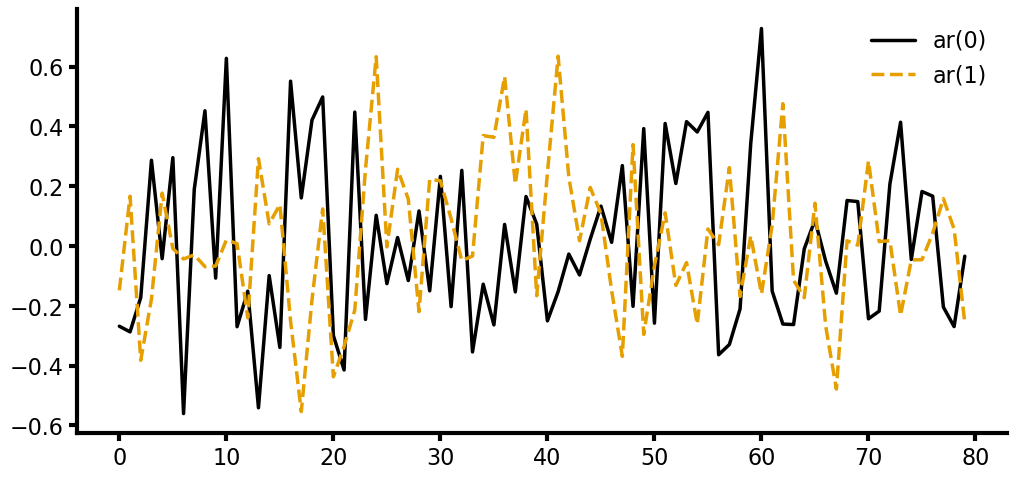

In [6]:
times = np.arange(0, len(f_co2_ssp2_lo)-1, 1)

# set random variables
np.random.seed(48)
ar0_noise_ts = np.random.normal(0, noise_var, size=(len(times)))
ar1_noise_ts = np.zeros_like(times, dtype=float)
ar1_noise_ts[0] = np.random.normal(0, noise_var)  # set initial condition of ar(1) time series

for t in range(1, len(times)):
    ar1_noise_ts[t] = auto_corr * ar1_noise_ts[t-1] + np.random.normal(0, noise_var)

# check plots
plt.plot(times, ar0_noise_ts, label='ar(0)')
plt.plot(times, ar1_noise_ts, label='ar(1)')
plt.legend()
plt.show()

In [7]:
# empty arrays for SNRs
timess = np.arange(0, 70, 1)
snr_nn_ssp2_lo = np.zeros_like(timess, dtype=float)
snr_ar0_ssp2_lo = np.zeros_like(timess, dtype=float)
snr_ar1_ssp2_lo = np.zeros_like(timess, dtype=float)

snr_nn_ssp2_hi = np.zeros_like(timess, dtype=float)
snr_ar0_ssp2_hi = np.zeros_like(timess, dtype=float)
snr_ar1_ssp2_hi = np.zeros_like(timess, dtype=float)

snr_nn_ssp5_lo = np.zeros_like(timess, dtype=float)
snr_ar0_ssp5_lo = np.zeros_like(timess, dtype=float)
snr_ar1_ssp5_lo = np.zeros_like(timess, dtype=float)

snr_nn_ssp5_hi = np.zeros_like(timess, dtype=float)
snr_ar0_ssp5_hi = np.zeros_like(timess, dtype=float)
snr_ar1_ssp5_hi = np.zeros_like(timess, dtype=float)

In [8]:
"""Version with cross terms. Only run for t = 70 (something wrong with geo time series?)
def compute_snr(t, e, L, G, EPS, F2x, noise_ts, noise_var, auto_corr):
    upper = np.mean(
        np.abs(e.forcing['geo'][:t])**2
    )

    lower = np.mean(
        (F2x * np.log(e.conc['CO2'][:t] / e.conc['CO2'][0]))**2
    ) + noise_var**2 / (1 - auto_corr**2) + np.mean(
        np.abs(e.forcing['geo'][:t])**2
    ) - 2 * np.mean(F2x * np.log(e.conc['CO2'][:t] / e.conc['CO2'][0])) * np.abs(e.forcing['geo'][:t])


    return upper / lower
"""

"Version with cross terms. Only run for t = 70 (something wrong with geo time series?)\ndef compute_snr(t, e, L, G, EPS, F2x, noise_ts, noise_var, auto_corr):\n    upper = np.mean(\n        np.abs(e.forcing['geo'][:t])**2\n    )\n\n    lower = np.mean(\n        (F2x * np.log(e.conc['CO2'][:t] / e.conc['CO2'][0]))**2\n    ) + noise_var**2 / (1 - auto_corr**2) + np.mean(\n        np.abs(e.forcing['geo'][:t])**2\n    ) - 2 * np.mean(F2x * np.log(e.conc['CO2'][:t] / e.conc['CO2'][0])) * np.abs(e.forcing['geo'][:t])\n\n\n    return upper / lower\n"

In [9]:
def compute_snr(t, e, L, G, EPS, F2x, noise_ts, noise_var, auto_corr):
    noise_ts = np.zeros(t)
    noise_ts[0] = np.random.normal(loc=0, scale=noise_var)
    for ti in range(1, t):
        noise_ts[ti] = auto_corr * noise_ts[ti-1] + np.random.normal(loc=0, scale=noise_var)

    upper = np.cumsum(
        np.abs(e.forcing['geo'][:t])
    )**2

    lower = np.cumsum(( (F2x * np.log(e.conc['CO2'][:t] / e.conc['CO2'][0])) + noise_ts ) **2 )
    #+ noise_var**2 / (1 - auto_corr**2) 
    #+ (noise_var / np.sqrt(1 - auto_corr**2)) * np.cumsum(
    #    (F2x * np.log(e.conc['CO2'][:t] / e.conc['CO2'][0]) ))
    #)

    # print(upper, lower)

    return (upper / lower)[-1]

In [24]:
def compute_snr(t, e, L, G, EPS, F2x, noise_ts, noise_var, auto_corr):
    co2 = F2x * np.log(e.conc['CO2'][t] / e.conc["CO2"][0])
    geo = np.abs(e.forcing['geo'][t])

    upper = np.cumsum(geo / co2)[-1]

    correction = (
        t * ((1 - auto_corr) / (1 + auto_corr))
    )
    denom = 0.519**2 + noise_var 

    snr = upper / np.sqrt(denom)
    snr *= correction

    #lower = [(np.cumsum((F2x * np.log(e.conc['CO2'][:t] / e.conc['CO2'][0])))**2 
    #+ samp_std**2 * t * ((1 + auto_corr) / (1 - auto_corr))
    #)[-1] for (f, l, g, ep) in zip(fs, ls, gs, es)]
    #+ (samp_std / np.sqrt(1 - auto_corr**2)) * np.cumsum(
    #    (f * np.log(e.conc['CO2'][:t] / e.conc['CO2'][0]) / (l + g * ep) )))[-1] for (f, l, g, ep) in zip(fs, ls, gs, es)]
    #lower = np.mean(lower)

    # print(upper, lower)

    return snr

In [25]:
fvar = 0.519**2 + (L * 0.3)**2 + (G * 0.3)**2 + 0.159**2
lower = np.sqrt(
        fvar + (noise_var / t) * ((1 - auto_corr) / (1 + auto_corr))
        )

In [26]:
for t in range(1, 70):
    snr_nn_ssp2_lo[t] = compute_snr(t, e_ssp2_lo, L, G, EPS, F2x, None, 0.0, 0.0)
    snr_ar0_ssp2_lo[t] = compute_snr(t, e_ssp2_lo, L, G, EPS, F2x, None, noise_var, 0.0)
    snr_ar1_ssp2_lo[t] = compute_snr(t, e_ssp2_lo, L, G, EPS, F2x, None, noise_var, auto_corr)
    
    snr_nn_ssp2_hi[t] = compute_snr(t, e_ssp2_hi, L, G, EPS, F2x, None, 0.0, 0.0)
    snr_ar0_ssp2_hi[t] = compute_snr(t, e_ssp2_hi, L, G, EPS, F2x, None, noise_var, 0.0)
    snr_ar1_ssp2_hi[t] = compute_snr(t, e_ssp2_hi, L, G, EPS, F2x, None, noise_var, auto_corr)

    snr_nn_ssp5_lo[t] = compute_snr(t, e_ssp5_lo, L, G, EPS, F2x, None, 0.0, 0.0)
    snr_ar0_ssp5_lo[t] = compute_snr(t, e_ssp5_lo, L, G, EPS, F2x, None, noise_var, 0.0)
    snr_ar1_ssp5_lo[t] = compute_snr(t, e_ssp5_lo, L, G, EPS, F2x, None, noise_var, auto_corr)

    snr_nn_ssp5_hi[t] = compute_snr(t, e_ssp5_hi, L, G, EPS, F2x, None, 0.0, 0.0)
    snr_ar0_ssp5_hi[t] = compute_snr(t, e_ssp5_hi, L, G, EPS, F2x, None, noise_var, 0.0)
    snr_ar1_ssp5_hi[t] = compute_snr(t, e_ssp5_hi, L, G, EPS, F2x, None, noise_var, auto_corr)


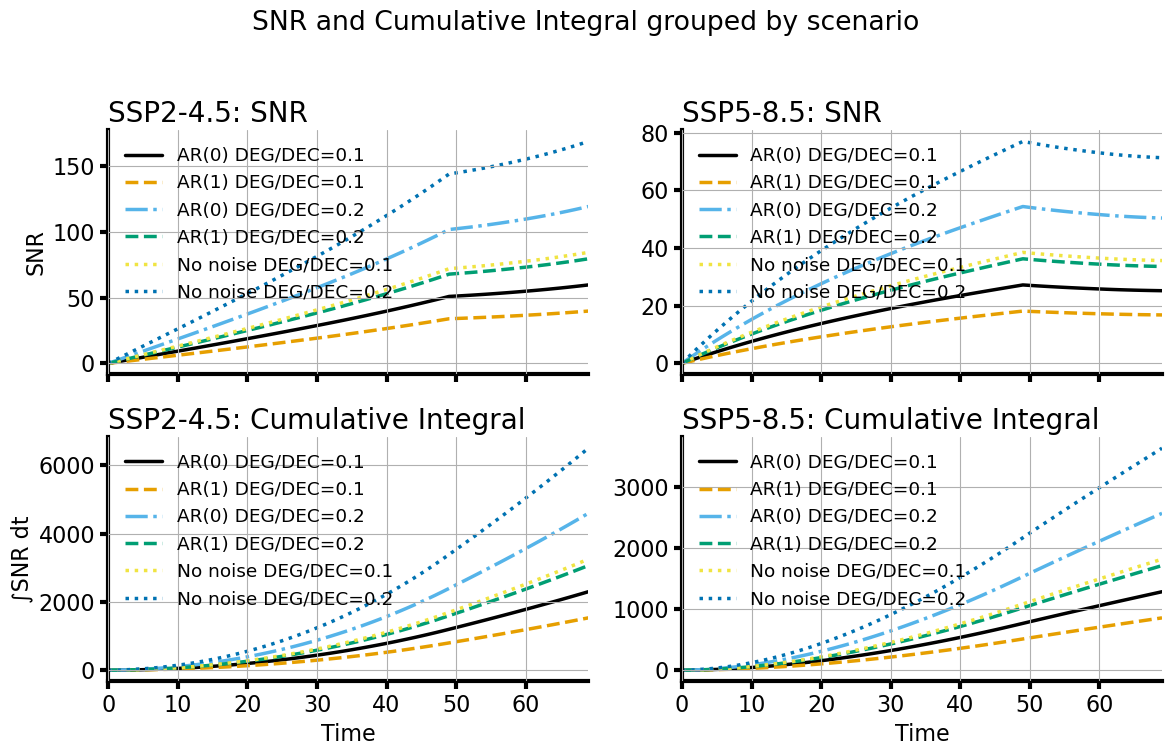

In [28]:
# Grouped by scenario: left = all SSP2, right = all SSP5
# Now with 2 rows: top = original SNR, bottom = cumulative integral
fig, axs = plt.subplots(2, 2, figsize=(12, 8), sharex=True)

# Calculate time step for integration (assuming uniform spacing)
dt = timess[1] - timess[0] if len(timess) > 1 else 1

# Helper function to compute cumulative integral, ignoring NaNs
def cumulative_integral(y, dt):
    y_clean = np.where(np.isnan(y), 0, y)  # Replace NaNs with 0
    return np.cumsum(y_clean) * dt

# ===== TOP ROW: Original SNR plots =====
# SSP2 (top left)
axs[0, 0].plot(timess, snr_ar0_ssp2_lo, label='AR(0) DEG/DEC=0.1')
axs[0, 0].plot(timess, snr_ar1_ssp2_lo, linestyle='--', label='AR(1) DEG/DEC=0.1')
axs[0, 0].plot(timess, snr_ar0_ssp2_hi, label='AR(0) DEG/DEC=0.2')
axs[0, 0].plot(timess, snr_ar1_ssp2_hi, linestyle='--', label='AR(1) DEG/DEC=0.2')
axs[0, 0].plot(timess, snr_nn_ssp2_lo, linestyle=':', label='No noise DEG/DEC=0.1')
axs[0, 0].plot(timess, snr_nn_ssp2_hi, linestyle=':', label='No noise DEG/DEC=0.2')
axs[0, 0].set_title('SSP2-4.5: SNR')
axs[0, 0].set_xlim((timess[0], timess[-1]))
axs[0, 0].grid(True)
axs[0, 0].legend(fontsize='small')
axs[0, 0].set_ylabel('SNR')

# SSP5 (top right)
axs[0, 1].plot(timess, snr_ar0_ssp5_lo, label='AR(0) DEG/DEC=0.1')
axs[0, 1].plot(timess, snr_ar1_ssp5_lo, linestyle='--', label='AR(1) DEG/DEC=0.1')
axs[0, 1].plot(timess, snr_ar0_ssp5_hi, label='AR(0) DEG/DEC=0.2')
axs[0, 1].plot(timess, snr_ar1_ssp5_hi, linestyle='--', label='AR(1) DEG/DEC=0.2')
axs[0, 1].plot(timess, snr_nn_ssp5_lo, linestyle=':', label='No noise DEG/DEC=0.1')
axs[0, 1].plot(timess, snr_nn_ssp5_hi, linestyle=':', label='No noise DEG/DEC=0.2')
axs[0, 1].set_title('SSP5-8.5: SNR')
axs[0, 1].set_xlim((timess[0], timess[-1]))
axs[0, 1].grid(True)
axs[0, 1].legend(fontsize='small')

# ===== BOTTOM ROW: Cumulative integrals =====
# SSP2 integral (bottom left)
axs[1, 0].plot(timess, cumulative_integral(snr_ar0_ssp2_lo, dt), label='AR(0) DEG/DEC=0.1')
axs[1, 0].plot(timess, cumulative_integral(snr_ar1_ssp2_lo, dt), linestyle='--', label='AR(1) DEG/DEC=0.1')
axs[1, 0].plot(timess, cumulative_integral(snr_ar0_ssp2_hi, dt), label='AR(0) DEG/DEC=0.2')
axs[1, 0].plot(timess, cumulative_integral(snr_ar1_ssp2_hi, dt), linestyle='--', label='AR(1) DEG/DEC=0.2')
axs[1, 0].plot(timess, cumulative_integral(snr_nn_ssp2_lo, dt), linestyle=':', label='No noise DEG/DEC=0.1')
axs[1, 0].plot(timess, cumulative_integral(snr_nn_ssp2_hi, dt), linestyle=':', label='No noise DEG/DEC=0.2')
axs[1, 0].set_title('SSP2-4.5: Cumulative Integral')
axs[1, 0].set_xlim((timess[0], timess[-1]))
axs[1, 0].grid(True)
axs[1, 0].legend(fontsize='small')
axs[1, 0].set_ylabel('∫SNR dt')
axs[1, 0].set_xlabel('Time')

# SSP5 integral (bottom right)
axs[1, 1].plot(timess, cumulative_integral(snr_ar0_ssp5_lo, dt), label='AR(0) DEG/DEC=0.1')
axs[1, 1].plot(timess, cumulative_integral(snr_ar1_ssp5_lo, dt), linestyle='--', label='AR(1) DEG/DEC=0.1')
axs[1, 1].plot(timess, cumulative_integral(snr_ar0_ssp5_hi, dt), label='AR(0) DEG/DEC=0.2')
axs[1, 1].plot(timess, cumulative_integral(snr_ar1_ssp5_hi, dt), linestyle='--', label='AR(1) DEG/DEC=0.2')
axs[1, 1].plot(timess, cumulative_integral(snr_nn_ssp5_lo, dt), linestyle=':', label='No noise DEG/DEC=0.1')
axs[1, 1].plot(timess, cumulative_integral(snr_nn_ssp5_hi, dt), linestyle=':', label='No noise DEG/DEC=0.2')
axs[1, 1].set_title('SSP5-8.5: Cumulative Integral')
axs[1, 1].set_xlim((timess[0], timess[-1]))
axs[1, 1].grid(True)
axs[1, 1].legend(fontsize='small')
axs[1, 1].set_xlabel('Time')

fig.suptitle('SNR and Cumulative Integral grouped by scenario')
fig.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.show()

# fig.savefig('figs/2026-2-6-snr-mental-model-sota.png', dpi=300)

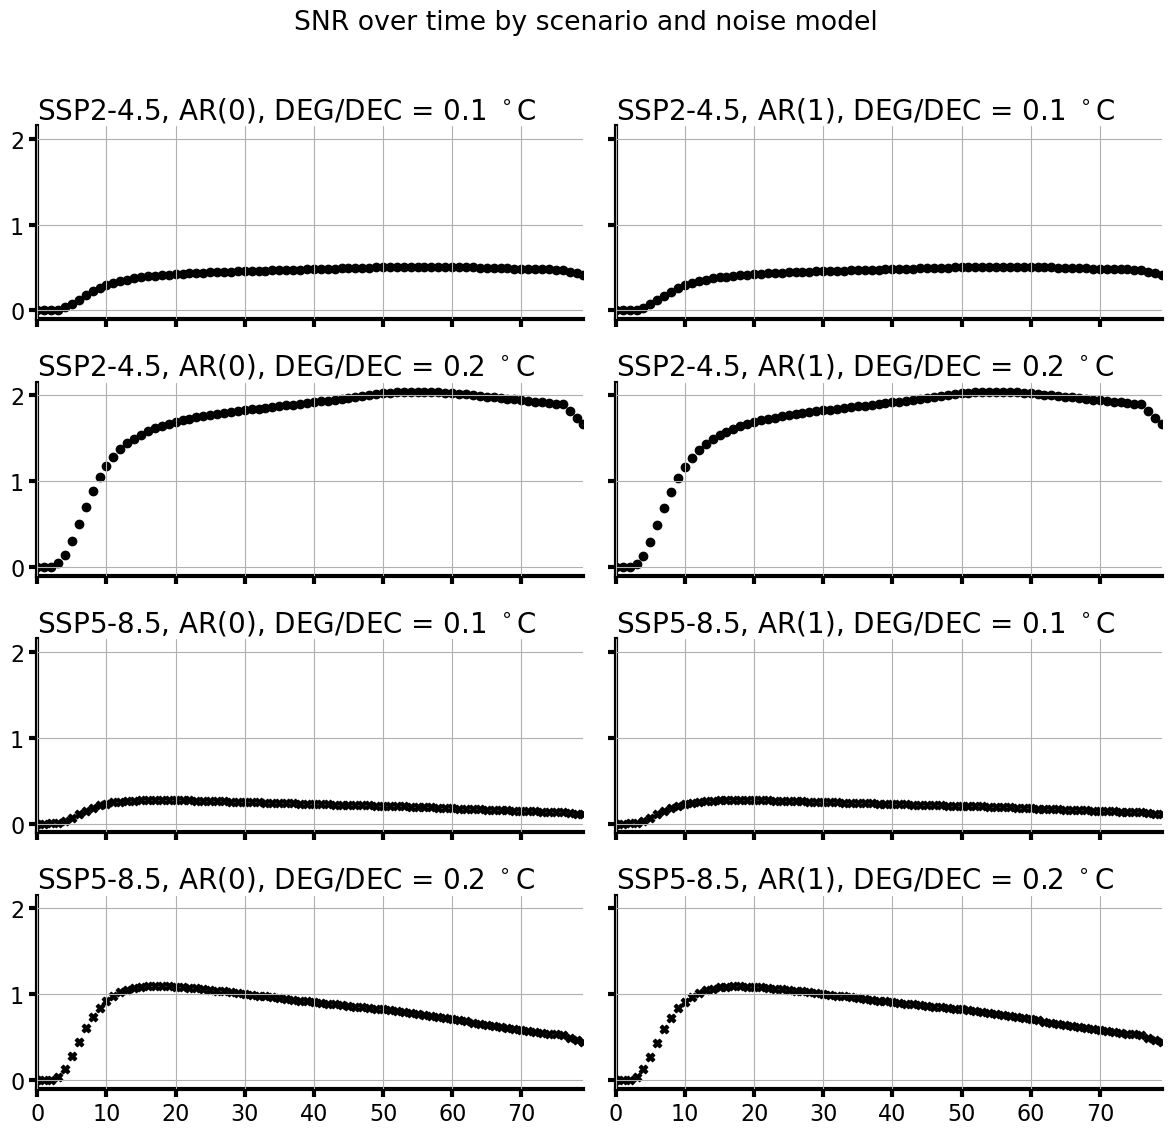

In [66]:
fig, axs = plt.subplots(4, 2, figsize=(12, 12), sharex=True, sharey=True)
axs = axs.flatten()

series = [
    (snr_ar0_ssp2_lo, r"SSP2-4.5, AR(0), DEG/DEC = 0.1 $^\circ$C", 'o'),
    (snr_ar1_ssp2_lo, r"SSP2-4.5, AR(1), DEG/DEC = 0.1 $^\circ$C", 'o'),
    (snr_ar0_ssp2_hi, r"SSP2-4.5, AR(0), DEG/DEC = 0.2 $^\circ$C", 'o'),
    (snr_ar1_ssp2_hi, r"SSP2-4.5, AR(1), DEG/DEC = 0.2 $^\circ$C", 'o'),
    (snr_ar0_ssp5_lo, r"SSP5-8.5, AR(0), DEG/DEC = 0.1 $^\circ$C", 'X'),
    (snr_ar1_ssp5_lo, r"SSP5-8.5, AR(1), DEG/DEC = 0.1 $^\circ$C", 'X'),
    (snr_ar0_ssp5_hi, r"SSP5-8.5, AR(0), DEG/DEC = 0.2 $^\circ$C", 'X'),
    (snr_ar1_ssp5_hi, r"SSP5-8.5, AR(1), DEG/DEC = 0.2 $^\circ$C", 'X'),
]

for ax, (data, title, marker) in zip(axs, series):
    ax.scatter(times, data, marker=marker)
    ax.set_title(title)
    ax.set_xlim((times[0], times[-1]))
    ax.grid(True)

fig.suptitle('SNR over time by scenario and noise model')
fig.tight_layout(rect=[0, 0.03, 1, 0.97])

plt.show()


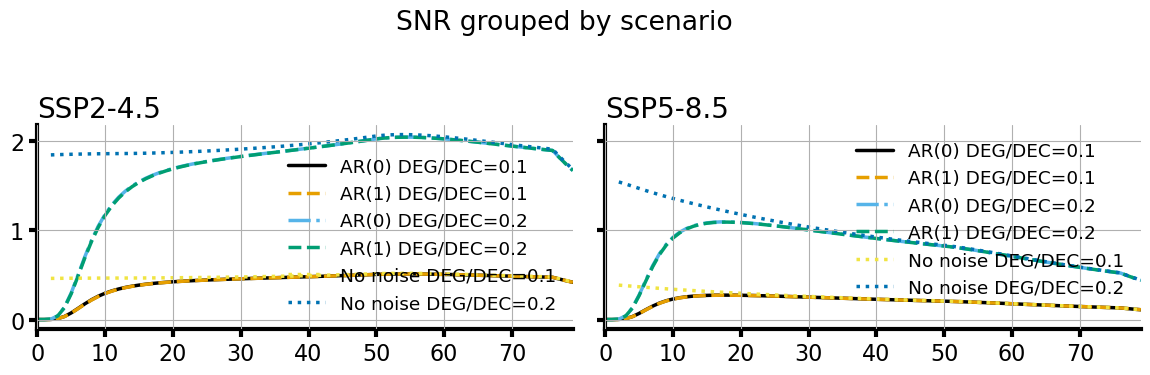

In [67]:
# Grouped by scenario: left = all SSP2, right = all SSP5
fig, axs = plt.subplots(1, 2, figsize=(12, 4), sharex=True, sharey=True)

# SSP2 (left)
axs[0].plot(times, snr_ar0_ssp2_lo, label='AR(0) DEG/DEC=0.1')
axs[0].plot(times, snr_ar1_ssp2_lo, linestyle='--', label='AR(1) DEG/DEC=0.1')
axs[0].plot(times, snr_ar0_ssp2_hi, label='AR(0) DEG/DEC=0.2')
axs[0].plot(times, snr_ar1_ssp2_hi, linestyle='--', label='AR(1) DEG/DEC=0.2')
# No-noise series for SSP2
axs[0].plot(times, snr_nn_ssp2_lo, linestyle=':', label='No noise DEG/DEC=0.1')
axs[0].plot(times, snr_nn_ssp2_hi, linestyle=':', label='No noise DEG/DEC=0.2')
axs[0].set_title('SSP2-4.5')
axs[0].set_xlim((times[0], times[-1]))
axs[0].grid(True)
axs[0].legend(fontsize='small')

# SSP5 (right)
axs[1].plot(times, snr_ar0_ssp5_lo, label='AR(0) DEG/DEC=0.1')
axs[1].plot(times, snr_ar1_ssp5_lo, linestyle='--', label='AR(1) DEG/DEC=0.1')
axs[1].plot(times, snr_ar0_ssp5_hi, label='AR(0) DEG/DEC=0.2')
axs[1].plot(times, snr_ar1_ssp5_hi, linestyle='--', label='AR(1) DEG/DEC=0.2')
# No-noise series for SSP5
axs[1].plot(times, snr_nn_ssp5_lo, linestyle=':', label='No noise DEG/DEC=0.1')
axs[1].plot(times, snr_nn_ssp5_hi, linestyle=':', label='No noise DEG/DEC=0.2')
axs[1].set_title('SSP5-8.5')
axs[1].set_xlim((times[0], times[-1]))
axs[1].grid(True)
axs[1].legend(fontsize='small')

fig.suptitle('SNR grouped by scenario')
fig.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


In [54]:
snr_nn_ssp2_lo

array([0.        ,        nan, 0.46082587, 0.46148118, 0.46203534,
       0.46251917, 0.46296465, 0.46334424, 0.46366762, 0.46394791,
       0.46417583, 0.46436001, 0.46450433, 0.46465626, 0.4648744 ,
       0.46517664, 0.4655659 , 0.46603551, 0.46657448, 0.46717358,
       0.46782357, 0.46851563, 0.46924287, 0.47000983, 0.47082688,
       0.47170015, 0.47263114, 0.47361985, 0.47466464, 0.47576271,
       0.47691188, 0.47810864, 0.47935028, 0.48064149, 0.48199221,
       0.48341006, 0.48489913, 0.48646207, 0.48810042, 0.48981451,
       0.49160377, 0.49346728, 0.49540387, 0.49741522, 0.49950498,
       0.50167558, 0.50392877, 0.50626548, 0.50868598, 0.51119052,
       0.51377839, 0.51563946, 0.51685536, 0.51750432, 0.51765987,
       0.51738742, 0.51674506, 0.51578432, 0.51455088, 0.51308517,
       0.51142295, 0.50959614, 0.50763278, 0.50555969, 0.50340226,
       0.50118264, 0.49892031, 0.49663246, 0.49433418, 0.49203865,
       0.48975754, 0.48750114, 0.48527831, 0.48309447, 0.48095

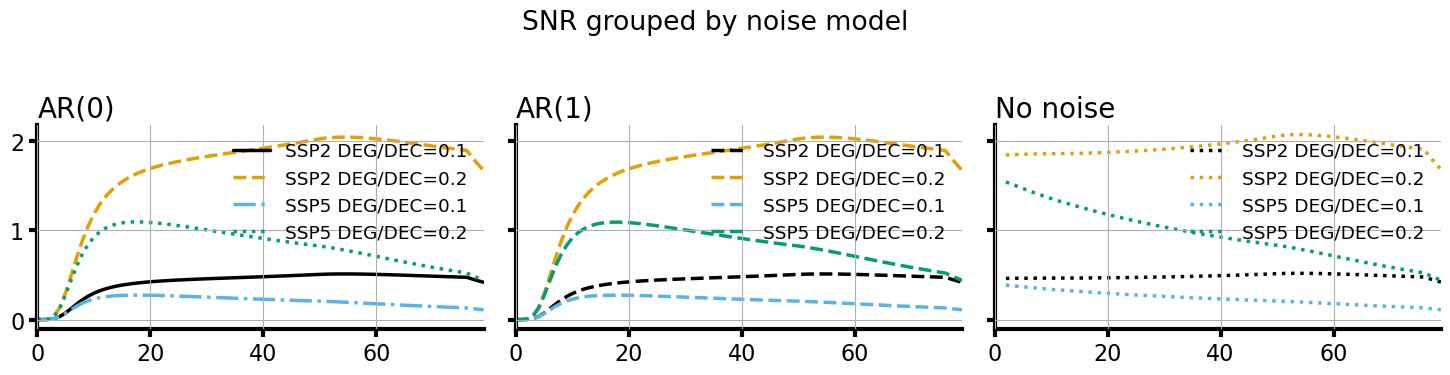

In [50]:
# Grouped by noise model: panels = AR(0), AR(1), No noise
fig, axs = plt.subplots(1, 3, figsize=(15, 4), sharex=True, sharey=True)

# AR(0)
axs[0].plot(times, snr_ar0_ssp2_lo, label='SSP2 DEG/DEC=0.1')
axs[0].plot(times, snr_ar0_ssp2_hi, label='SSP2 DEG/DEC=0.2')
axs[0].plot(times, snr_ar0_ssp5_lo, label='SSP5 DEG/DEC=0.1')
axs[0].plot(times, snr_ar0_ssp5_hi, label='SSP5 DEG/DEC=0.2')
axs[0].set_title('AR(0)')
axs[0].set_xlim((times[0], times[-1]))
axs[0].grid(True)
axs[0].legend(fontsize='small')

# AR(1)
axs[1].plot(times, snr_ar1_ssp2_lo, linestyle='--', label='SSP2 DEG/DEC=0.1')
axs[1].plot(times, snr_ar1_ssp2_hi, linestyle='--', label='SSP2 DEG/DEC=0.2')
axs[1].plot(times, snr_ar1_ssp5_lo, linestyle='--', label='SSP5 DEG/DEC=0.1')
axs[1].plot(times, snr_ar1_ssp5_hi, linestyle='--', label='SSP5 DEG/DEC=0.2')
axs[1].set_title('AR(1)')
axs[1].set_xlim((times[0], times[-1]))
axs[1].grid(True)
axs[1].legend(fontsize='small')

# No noise
axs[2].plot(times, snr_nn_ssp2_lo, linestyle=':', label='SSP2 DEG/DEC=0.1')
axs[2].plot(times, snr_nn_ssp2_hi, linestyle=':', label='SSP2 DEG/DEC=0.2')
axs[2].plot(times, snr_nn_ssp5_lo, linestyle=':', label='SSP5 DEG/DEC=0.1')
axs[2].plot(times, snr_nn_ssp5_hi, linestyle=':', label='SSP5 DEG/DEC=0.2')
axs[2].set_title('No noise')
axs[2].set_xlim((times[0], times[-1]))
axs[2].grid(True)
axs[2].legend(fontsize='small')

fig.suptitle('SNR grouped by noise model')
fig.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

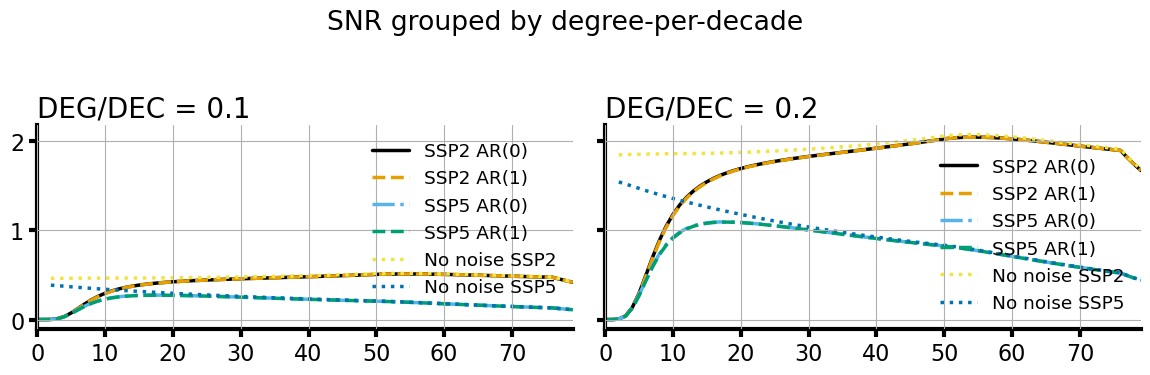

In [51]:
# Grouped by degree-per-decade: left = DEG/DEC 0.1, right = DEG/DEC 0.2
fig, axs = plt.subplots(1, 2, figsize=(12, 4), sharex=True, sharey=True)

# DEG/DEC = 0.1
axs[0].plot(times, snr_ar0_ssp2_lo, label='SSP2 AR(0)')
axs[0].plot(times, snr_ar1_ssp2_lo, linestyle='--', label='SSP2 AR(1)')
axs[0].plot(times, snr_ar0_ssp5_lo, label='SSP5 AR(0)')
axs[0].plot(times, snr_ar1_ssp5_lo, linestyle='--', label='SSP5 AR(1)')
# No-noise series (grouped with deg/dec 0.1)
axs[0].plot(times, snr_nn_ssp2_lo, linestyle=':', label='No noise SSP2')
axs[0].plot(times, snr_nn_ssp5_lo, linestyle=':', label='No noise SSP5')
axs[0].set_title('DEG/DEC = 0.1')
axs[0].set_xlim((times[0], times[-1]))
axs[0].grid(True)
axs[0].legend(fontsize='small')

# DEG/DEC = 0.2
axs[1].plot(times, snr_ar0_ssp2_hi, label='SSP2 AR(0)')
axs[1].plot(times, snr_ar1_ssp2_hi, linestyle='--', label='SSP2 AR(1)')
axs[1].plot(times, snr_ar0_ssp5_hi, label='SSP5 AR(0)')
axs[1].plot(times, snr_ar1_ssp5_hi, linestyle='--', label='SSP5 AR(1)')

# No-noise series (grouped with deg/dec 0.2)
axs[1].plot(times, snr_nn_ssp2_hi, linestyle=':', label='No noise SSP2')
axs[1].plot(times, snr_nn_ssp5_hi, linestyle=':', label='No noise SSP5')
axs[1].set_title('DEG/DEC = 0.2')
axs[1].set_xlim((times[0], times[-1]))
axs[1].grid(True)

axs[1].legend(fontsize='small')

fig.suptitle('SNR grouped by degree-per-decade')
fig.tight_layout(rect=[0, 0.03, 1, 0.95])

plt.show()

In [44]:
snr_ar0_ssp2_lo - snr_ar1_ssp2_lo

array([0.00000000e+00, 0.00000000e+00, 3.18685165e-07, 9.78722401e-07,
       1.94611269e-06, 3.19785090e-06, 4.71387801e-06, 6.47568133e-06,
       8.46591877e-06, 1.06682557e-05, 1.30672164e-05, 1.56481814e-05,
       1.83973029e-05, 2.13017401e-05, 2.43496884e-05, 2.75300337e-05,
       3.08323402e-05, 3.42467729e-05, 3.77640474e-05, 4.13754453e-05,
       4.50727505e-05, 4.88482140e-05, 5.26945552e-05, 5.66052301e-05,
       6.05743972e-05, 6.45966367e-05, 6.86668505e-05, 7.27803005e-05,
       7.69325494e-05, 8.11194344e-05, 8.53371174e-05, 8.95819580e-05,
       9.38506024e-05, 9.81404437e-05, 1.02449617e-04, 1.06776507e-04,
       1.11119581e-04, 1.15477481e-04, 1.19849006e-04, 1.24233063e-04,
       1.28628655e-04, 1.33034900e-04, 1.37451029e-04, 1.41876746e-04,
       1.46312178e-04, 1.50757492e-04, 1.55212927e-04, 1.59678743e-04,
       1.64155218e-04, 1.68642717e-04, 1.73141538e-04, 1.77242363e-04,
       1.80978247e-04, 1.84380155e-04, 1.87477000e-04, 1.90295176e-04,
      

The gameplan is to analyze, for a single angle, possible learning timescales. I will then extend to multiple angles.

In [3]:
# simulation config
cwd = Path(os.getcwd())
prefix = 'margobs_ws'
ssp = 'ssp245'
model = 'pco2geowc'
TMIN = 2025
AR = '1'
THETA = 14
ECS = 3.0
DEGpDEC_hi = '0.2'
DEGpDEC_lo = '0.1'
NYRSRAMP = 50
Nwinds = '14custom'
Nens = 500

fnames = [
    cwd.parent.parent / 'model' / 'data' / 'output' / 'pco2geowc' / 'margobs_ws_ssp245_pco2geowc_TMIN2025_AR1_THETA{}_ECS3.0_DEGpDEC0.1_NYRSRAMP50_Nwinds14custom_Nens500.nc'.format(THETA),
    cwd.parent.parent / 'model' / 'data' / 'output' / 'pco2geowc' / 'margobs_ws_ssp245_pco2geowc_TMIN2025_AR0_THETA{}_ECS3.0_DEGpDEC0.1_NYRSRAMP50_Nwinds14custom_Nens500.nc'.format(THETA),
    cwd.parent.parent / 'model' / 'data' / 'output' / 'pco2geowc_nn' / 'margobs_ws_nonoise_ssp245_pco2geowc_nn_TMIN2025_THETA{}_ECS3.0_DEGpDEC0.1_NYRSRAMP50_Nwinds14custom_Nens500.nc'.format(THETA),
    cwd.parent.parent / 'model' / 'data' / 'output' / 'pco2geowc' / 'margobs_ws_ssp245_pco2geowc_TMIN2025_AR1_THETA{}_ECS3.0_DEGpDEC0.2_NYRSRAMP50_Nwinds14custom_Nens500.nc'.format(THETA),
    cwd.parent.parent / 'model' / 'data' / 'output' / 'pco2geowc3' / 'margobs_ws_ssp245_pco2geowc3_TMIN2025_AR1_THETA{}_ECS3.0_DEGpDEC0.1_NYRSRAMP50_Nwinds14custom_Nens500.nc'.format(THETA),
]

dts = [open_datatree(f, engine='netcdf4') for f in fnames]
labels = ['AR(1)', 'AR(0)', 'No noise', 'Hi Geo', 'Three region']

# make assimilation windows -- ALWAYS CHECK THIS MATCHES THE ABOVE
winds = np.hstack([np.arange(2027, 2050, 2), [2075, 2100]])
windss = [str(w) for w in winds]

In [4]:
ens_angles = np.zeros((len(dts), len(windss), Nens))  # SAI angles for each file, at each observational assimilation window, for each ensemble member

In [5]:
# important simulation constants
L_CEN = 4.58 * np.log(2) / ECS  # central value of feedback parameter
G_CEN = 0.7
EPS_CEN = 1.58
F_EFF_GEO = 0.09  # efficacy
ALPHA_R1_CEN = 2.0  # central value of alpha r1 dist
ALPHA_R2_CEN = 1.3  # central value of alpha r2 dist

## Filtering dev

In [6]:
ds = dts[0]['2049'].ds

In [7]:
ds

<xarray.DatasetView>
Dimensions:         (ens_mem: 500, vari: 40, time: 25, iter: 101, obs_var: 4)
Coordinates:
  * time            (time) float64 2.025e+03 2.026e+03 ... 2.048e+03 2.049e+03
  * iter            (iter) int64 0 1 2 3 4 5 6 7 8 ... 93 94 95 96 97 98 99 100
  * vari            (vari) object 'T1' 'T2' 'Q' 'T_R1' ... 'q22' 'q23' 'q24'
  * ens_mem         (ens_mem) int64 0 1 2 3 4 5 6 ... 494 495 496 497 498 499
  * obs_var         (obs_var) object 'T1' 'Q' 'T_R1' 'T_R2'
Data variables:
    data_final      (ens_mem, vari, time) float64 ...
    l2s             (ens_mem) float64 ...
    costs           (ens_mem) float64 ...
    controls        (ens_mem, vari) float64 ...
    data_hist       (ens_mem, vari, iter, time) float64 ...
    l2_hist         (ens_mem, iter) float64 ...
    cost_hist       (ens_mem, iter) float64 ...
    controls_hist   (ens_mem, vari, iter) float64 ...
    flag            (ens_mem) int64 ...
    obs             (obs_var, time) float64 ...
    data_truth      (vari, time) float64 ...
    controls_truth  (vari) float64 ...
Attributes:
    tol:                       0.001
    TMIN:                      2025
    DT:                        1.0
    TMAX:                      2049
    assim_tmax:                [2027 2029 2031 2033 2035 2037 2039 2041 2043 ...
    ANGLE:                     14
    run_time:                  252.4672875404358
    internal_variability_std:  0.27
    ECS:                       3.0
    max_iter:                  100

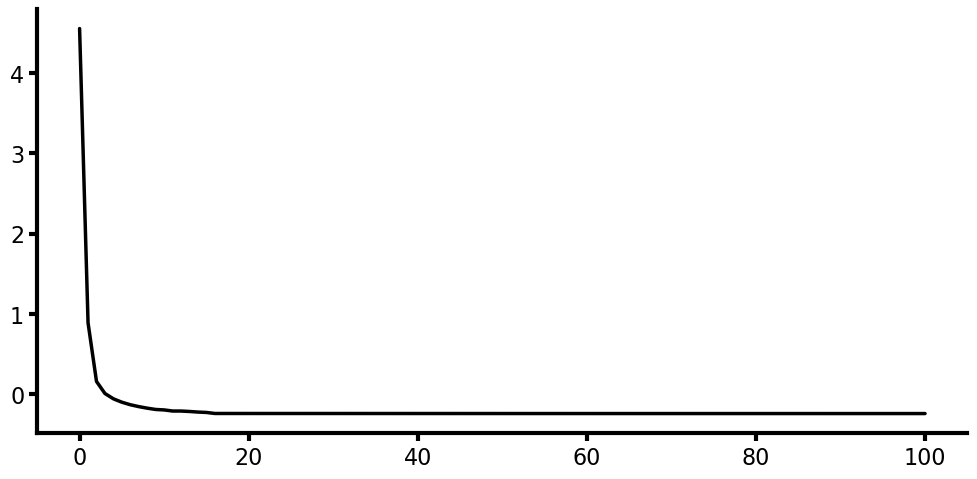

In [8]:
costhist = ds.cost_hist.sel(ens_mem=0).values
costf = ds.costs.sel(ens_mem=0).item()

plt.plot(np.log10(costhist))

## Two region angle calculations

In [9]:
# this is new and right (ง'̀-'́)ง
def get_angle_r2(a1, a2, b1, b2, l, e, g, phi=0.09):
    two_normed = np.array([a1, a2])
    inside = (l + e * g) / phi
    r_normed = -np.array([[b1 * inside - a1],
                        [b2 * inside - a2]])

    num = two_normed @ r_normed
    denom = np.sqrt(np.sum(two_normed**2) * np.sum(r_normed**2))
    return np.arccos(num / denom) * 180 / np.pi

These are copied over from the regional calibration file in `model/data/input`. Should probably directly import them sometime.

In [10]:
angles_tr = np.zeros(5)
a1_tr = [2.0] * 5
a2_tr = [1.3] * 5
b1_tr = [0.018, 0.018, 0.018, 0.018, 0.021]
b2_tr = [-0.0045, -0.011, -0.018, -0.023, -0.032]
l_tr = [L_CEN] * 5
g_tr = [G_CEN] * 5
e_tr = [EPS_CEN] * 5

for i in range(len(angles_tr)):
    angles_tr[i] = get_angle_r2(a1_tr[i], a2_tr[i], b1_tr[i], b2_tr[i], l_tr[i], e_tr[i], g_tr[i])

angles_tr = [angles_tr[0], angles_tr[2], angles_tr[4]]
angles_tr

[8.91821010610413, 14.850347038824106, 21.13149998791466]

In [11]:
# pull prior distributions
prior_a1 = dts[0]['2027'].ds.controls_hist.sel(vari='ALPHA_R1', iter=0).values
prior_b1 = dts[0]['2027'].ds.controls_hist.sel(vari='BETA_R1', iter=0).values
prior_a2 = dts[0]['2027'].ds.controls_hist.sel(vari='ALPHA_R2', iter=0).values
prior_b2 = dts[0]['2027'].ds.controls_hist.sel(vari='BETA_R2', iter=0).values
prior_l = dts[0]['2027'].ds.controls_hist.sel(vari='L', iter=0).values
prior_g = dts[0]['2027'].ds.controls_hist.sel(vari='G', iter=0).values
prior_eps = dts[0]['2027'].ds.controls_hist.sel(vari='EPS', iter=0).values

# compute priors
angles_prior_r2 = np.zeros(Nens)
for i in range(Nens):
    angles_prior_r2[i] = get_angle_r2(prior_a1[i], prior_a2[i], prior_b1[i], prior_b2[i], prior_l[i], prior_eps[i], prior_g[i])

# describe for the people
describe(angles_prior_r2)

DescribeResult(nobs=500, minmax=(2.1498398364124376, 36.999684193011696), mean=14.614054598287966, variance=21.933064203710426, skewness=0.5712376007894195, kurtosis=0.7489433645300116)

In [12]:
w_ = 0
d_ = 0
for dt in dts[:-1]:
    for w in windss:
        tmp_a1 = dt[w].ds.controls.sel(vari='ALPHA_R1').values
        tmp_a2 = dt[w].ds.controls.sel(vari='ALPHA_R2').values
        tmp_b1 = dt[w].ds.controls.sel(vari='BETA_R1').values
        tmp_b2 = dt[w].ds.controls.sel(vari='BETA_R2').values
        tmp_l = dt[w].ds.controls.sel(vari='L').values
        tmp_g = dt[w].ds.controls.sel(vari='G').values
        tmp_eps = dt[w].ds.controls.sel(vari='EPS').values
        for i in range(Nens):
            ens_angles[d_, w_, i] = get_angle_r2(tmp_a1[i], tmp_a2[i], tmp_b1[i], tmp_b2[i], tmp_l[i], tmp_eps[i], tmp_g[i])
        w_ += 1
    d_ += 1
    w_ = 0

/scratch/local/jobs/44726881/ipykernel_1113222/3287823208.py:8: RuntimeWarning: overflow encountered in matmul
  num = two_normed @ r_normed
/scratch/local/jobs/44726881/ipykernel_1113222/3287823208.py:9: RuntimeWarning: overflow encountered in square
  denom = np.sqrt(np.sum(two_normed**2) * np.sum(r_normed**2))
/scratch/local/jobs/44726881/ipykernel_1113222/3287823208.py:10: RuntimeWarning: invalid value encountered in divide
  return np.arccos(num / denom) * 180 / np.pi
/scratch/local/jobs/44726881/ipykernel_1113222/3287823208.py:9: RuntimeWarning: overflow encountered in double_scalars
  denom = np.sqrt(np.sum(two_normed**2) * np.sum(r_normed**2))
/scratch/local/jobs/44726881/ipykernel_1113222/3287823208.py:10: RuntimeWarning: invalid value encountered in arccos
  return np.arccos(num / denom) * 180 / np.pi


## Three region

In [13]:
# this is new and right (ง'̀-'́)ง
def get_angle_r3(a1, a2, a3, b1, b2, b3, l, e, g, phi=0.09):
    two_normed = np.array([a1, a2, a3])
    inside = (l + e * g) / phi
    r_normed = -np.array([[b1 * inside - a1],
                        [b2 * inside - a2],
                        [b3 * inside - a3]])

    num = two_normed @ r_normed
    denom = np.sqrt(np.sum(two_normed**2) * np.sum(r_normed**2))
    return np.arccos(num / denom) * 180 / np.pi

In [14]:
# pull prior distributions
prior_a1 = dts[-1]['2027'].ds.controls_hist.sel(vari='ALPHA_R1', iter=0).values
prior_b1 = dts[-1]['2027'].ds.controls_hist.sel(vari='BETA_R1', iter=0).values
prior_a2 = dts[-1]['2027'].ds.controls_hist.sel(vari='ALPHA_R2', iter=0).values
prior_b2 = dts[-1]['2027'].ds.controls_hist.sel(vari='BETA_R2', iter=0).values
prior_a3 = dts[-1]['2027'].ds.controls_hist.sel(vari='ALPHA_R3', iter=0).values
prior_b3 = dts[-1]['2027'].ds.controls_hist.sel(vari='BETA_R3', iter=0).values
prior_l = dts[-1]['2027'].ds.controls_hist.sel(vari='L', iter=0).values
prior_g = dts[-1]['2027'].ds.controls_hist.sel(vari='G', iter=0).values
prior_eps = dts[-1]['2027'].ds.controls_hist.sel(vari='EPS', iter=0).values

# compute priors
angles_prior_r3 = np.zeros(Nens)
for i in range(Nens):
    angles_prior_r3[i] = get_angle_r3(prior_a1[i], prior_a2[i], prior_a3[i],
                                prior_b1[i], prior_b2[i], prior_b3[i], 
                                prior_l[i], prior_eps[i], prior_g[i])

# describe for the people
describe(angles_prior_r3)

DescribeResult(nobs=500, minmax=(3.162238449009512, 29.767832667039293), mean=14.74499664628919, variance=21.605455585508107, skewness=0.5171109099801817, kurtosis=0.22182878357729674)

In [15]:
w_ = 0
for dt in [dts[-1]]:
    for w in windss:
        tmp_a1 = dt[w].ds.controls.sel(vari='ALPHA_R1').values
        tmp_a2 = dt[w].ds.controls.sel(vari='ALPHA_R2').values
        tmp_a3 = dt[w].ds.controls.sel(vari='ALPHA_R3').values
        tmp_b1 = dt[w].ds.controls.sel(vari='BETA_R1').values
        tmp_b2 = dt[w].ds.controls.sel(vari='BETA_R2').values
        tmp_b3 = dt[w].ds.controls.sel(vari='BETA_R3').values
        tmp_l = dt[w].ds.controls.sel(vari='L').values
        tmp_g = dt[w].ds.controls.sel(vari='G').values
        tmp_eps = dt[w].ds.controls.sel(vari='EPS').values
        for i in range(Nens):
            ens_angles[-1, w_, i] = get_angle_r3(tmp_a1[i], tmp_a2[i], tmp_a3[i],
                                          tmp_b1[i], tmp_b2[i], tmp_b3[i],
                                          tmp_l[i], tmp_eps[i], tmp_g[i])
        w_ += 1

/scratch/local/jobs/44726881/ipykernel_1113222/2267588331.py:9: RuntimeWarning: overflow encountered in matmul
  num = two_normed @ r_normed
/scratch/local/jobs/44726881/ipykernel_1113222/2267588331.py:10: RuntimeWarning: overflow encountered in square
  denom = np.sqrt(np.sum(two_normed**2) * np.sum(r_normed**2))
/scratch/local/jobs/44726881/ipykernel_1113222/2267588331.py:11: RuntimeWarning: invalid value encountered in divide
  return np.arccos(num / denom) * 180 / np.pi


In [16]:
ens_angles_filtered = np.where(ens_angles > np.percentile(ens_angles, 99.5), np.nan, ens_angles)

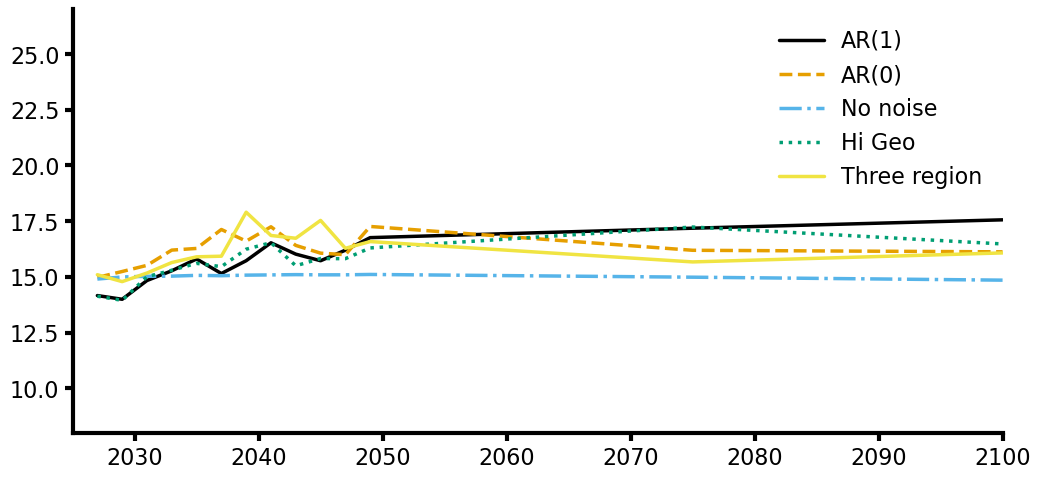

In [17]:
plt.plot(winds, np.nanmean(ens_angles_filtered[0], axis=1), label=labels[0])
plt.plot(winds, np.nanmean(ens_angles_filtered[1], axis=1), label=labels[1])
plt.plot(winds, np.nanmean(ens_angles_filtered[2], axis=1), label=labels[2])
plt.plot(winds, np.nanmean(ens_angles_filtered[3], axis=1), label=labels[3])
plt.plot(winds, np.nanmean(ens_angles_filtered[4], axis=1), label=labels[4])

plt.xlim((2025, 2100))
plt.ylim((8, 27))
plt.legend()

In [18]:
from src.emis import EmissionsBaseline
import scipy.integrate as integrate

Now do the calculation of the learning timescale

In [19]:
RHO = 0.2
tau_intvar = 1 / (1 - RHO)

In [20]:
def get_forcing(e, F1_CO2, t):
    """Compute forcing.
    """

    F_CO2 = F1_CO2 * np.log(e.conc['CO2'][t] / 278.3)
    F_GEO = e.forcing['geo'][t]
    return F_CO2 + F_GEO

def geo_only_path_r2(e, theta, TMIN, TMAX, DT):
    """Get nonlinear path for our model.
    """

    # unpack parameters
    params = theta[:15]
    (T10, T20, Q0, TR10, TR20, L, G, EPS, C1, C2, F1_CO2,
     ALPHA_R1, ALPHA_R2, BETA_R1, BETA_R2) = params
    qs = theta[15:]  # model errors

    # make time list and bare paths list
    times = np.arange(TMIN, TMAX + DT, DT)
    paths = np.zeros((len(theta), len(times)))

    # set ics
    paths[:, 0] = theta

    # only care about anomalies, so reset some initial conditions
    paths[0, 0] = qs[0] / C1
    paths[1, 0] = 0
    paths[2, 0] = qs[0]
    paths[3, 0] = ALPHA_R1 * paths[0, 0] + BETA_R1 * e.emis['geo'][0]
    paths[4, 0] = ALPHA_R2 * paths[0, 0] + BETA_R2 * e.emis['geo'][0]

    # paths[0] = T1, paths[1] = T2
    # iterate through time and integrate two layer model
    for t in range(1, len(times)):
        T1, T2 = paths[:2, t-1]
        F = get_forcing(e, 0.0, t-1)  # f = 0, we only care about geo
        paths[0, t] = (1 - DT * (L + G * EPS) * C1**(-1)) * T1\
            + DT * G * EPS * C1**(-1) * T2\
            + DT * C1**(-1) * F\
            + DT * C1**(-1) * qs[t]
        paths[1, t] = (1 - DT * G * C2**(-1)) * T2\
            + DT * G * C2**(-1) * T1

        # Q = T1 * C1 + T2 * C2
        paths[2, t] = paths[0, t] * C1 + paths[1, t] * C2

        # Tr = alpha_r * T1 - beta_r * geo_level
        paths[3, t] = ALPHA_R1 * paths[0, t]\
            + BETA_R1 * e.emis['geo'][t]
        
        paths[4, t] = ALPHA_R2 * paths[0, t]\
            + BETA_R2 * e.emis['geo'][t]

    # make stationary paths for parameters and model errors
    paths[5:] = np.array([
        [theta[5+i]] * len(times) for i in range(len(theta) - 5)])

    # integrate the surface temperature change
    int_temp_change_geo_only = integrate.simpson(paths[0])

    # return paths and times
    return -int_temp_change_geo_only

def get_path_r2(e, theta, TMIN, TMAX, DT):
    """Get nonlinear path for our model.
    """

    # unpack parameters
    params = theta[:15]
    (T10, T20, Q0, TR10, TR20, L, G, EPS, C1, C2, F1_CO2,
     ALPHA_R1, ALPHA_R2, BETA_R1, BETA_R2) = params
    qs = theta[15:]  # model errors

    # make time list and bare paths list
    times = np.arange(TMIN, TMAX + DT, DT)
    paths = np.zeros((len(theta), len(times)))

    # set ics
    paths[:, 0] = theta

    # only care about anomalies, so reset some initial conditions
    paths[0, 0] = qs[0] / C1
    paths[1, 0] = 0
    paths[2, 0] = qs[0]
    paths[3, 0] = ALPHA_R1 * paths[0, 0] + BETA_R1 * e.emis['geo'][0]
    paths[4, 0] = ALPHA_R2 * paths[0, 0] + BETA_R2 * e.emis['geo'][0]

    # paths[0] = T1, paths[1] = T2
    # iterate through time and integrate two layer model
    for t in range(1, len(times)):
        T1, T2 = paths[:2, t-1]
        F = get_forcing(e, F1_CO2, t-1)  # f = 0, we only care about geo
        paths[0, t] = (1 - DT * (L + G * EPS) * C1**(-1)) * T1\
            + DT * G * EPS * C1**(-1) * T2\
            + DT * C1**(-1) * F\
            + DT * C1**(-1) * qs[t]
        paths[1, t] = (1 - DT * G * C2**(-1)) * T2\
            + DT * G * C2**(-1) * T1

        # Q = T1 * C1 + T2 * C2
        paths[2, t] = paths[0, t] * C1 + paths[1, t] * C2

        # Tr = alpha_r * T1 - beta_r * geo_level
        paths[3, t] = ALPHA_R1 * paths[0, t]\
            + BETA_R1 * e.emis['geo'][t]
        
        paths[4, t] = ALPHA_R2 * paths[0, t]\
            + BETA_R2 * e.emis['geo'][t]

    # make stationary paths for parameters and model errors
    paths[5:] = np.array([
        [theta[5+i]] * len(times) for i in range(len(theta) - 5)])

    # integrate the surface temperature change
    int_temp_change_total = integrate.simpson(paths[0])

    # return paths and times
    return int_temp_change_total

In [ ]:
def get_path_nn(e, theta, TMIN, TMAX, DT):
    """Get nonlinear path for our model.
    """

    # unpack parameters
    (T10, T20, Q0, TR10, TR20, L, G, EPS, C1, C2, F1_CO2,
     ALPHA_R1, ALPHA_R2, BETA_R1, BETA_R2) = theta

    # make time list and bare paths list
    times = np.arange(TMIN, TMAX + DT, DT)
    paths = np.zeros((len(theta), len(times)))

    # set ics
    paths[:, 0] = theta

    # paths[0] = T1, paths[1] = T2
    # iterate through time and integrate two layer model
    for t in range(1, len(times)):
        T1, T2 = paths[:2, t-1]
        F = get_forcing(e, F1_CO2, t-1)
        paths[0, t] = (1 - DT * (L + G * EPS) * C1**(-1)) * T1\
            + DT * G * EPS * C1**(-1) * T2\
            + DT * C1**(-1) * F
        paths[1, t] = (1 - DT * G * C2**(-1)) * T2\
            + DT * G * C2**(-1) * T1

        # Q = T1 * C1 + T2 * C2
        paths[2, t] = paths[0, t] * C1 + paths[1, t] * C2

        # Tr = alpha_r * T1 + beta_r * geo_level
        paths[3, t] = ALPHA_R1 * paths[0, t]\
            + BETA_R1 * e.emis['geo'][t]
        
        paths[4, t] = ALPHA_R2 * paths[0, t]\
            + BETA_R2 * e.emis['geo'][t]

    # make stationary paths for parameters and model errors
    paths[5:] = np.array([
        [theta[5+i]] * len(times) for i in range(len(theta) - 5)])

    # integrate the surface temperature change
    int_temp_change_total = integrate.simpson(paths[0])

    # return paths and times
    return int_temp_change_total

def get_geo_path_nn(e, theta, TMIN, TMAX, DT):
    """Get nonlinear path for our model.
    """

    # unpack parameters
    (T10, T20, Q0, TR10, TR20, L, G, EPS, C1, C2, F1_CO2,
     ALPHA_R1, ALPHA_R2, BETA_R1, BETA_R2) = theta
    
    F1_CO2 = 0.

    # make time list and bare paths list
    times = np.arange(TMIN, TMAX + DT, DT)
    paths = np.zeros((len(theta), len(times)))

    # set ics
    paths[:, 0] = theta

    # paths[0] = T1, paths[1] = T2
    # iterate through time and integrate two layer model
    for t in range(1, len(times)):
        T1, T2 = paths[:2, t-1]
        F = get_forcing(e, F1_CO2, t-1)
        paths[0, t] = (1 - DT * (L + G * EPS) * C1**(-1)) * T1\
            + DT * G * EPS * C1**(-1) * T2\
            + DT * C1**(-1) * F
        paths[1, t] = (1 - DT * G * C2**(-1)) * T2\
            + DT * G * C2**(-1) * T1

        # Q = T1 * C1 + T2 * C2
        paths[2, t] = paths[0, t] * C1 + paths[1, t] * C2

        # Tr = alpha_r * T1 + beta_r * geo_level
        paths[3, t] = ALPHA_R1 * paths[0, t]\
            + BETA_R1 * e.emis['geo'][t]
        
        paths[4, t] = ALPHA_R2 * paths[0, t]\
            + BETA_R2 * e.emis['geo'][t]

    # make stationary paths for parameters and model errors
    paths[5:] = np.array([
        [theta[5+i]] * len(times) for i in range(len(theta) - 5)])

    # integrate the surface temperature change
    int_temp_change_total = integrate.simpson(paths[0])

    # return paths and times
    return -int_temp_change_total

In [ ]:
def get_path_r3(e, theta, TMIN, TMAX, DT):
    """Get nonlinear path for our model.
    """

    # unpack parameters
    params = theta[:18]
    (T10, T20, Q0, TR10, TR20, TR30, L, G, EPS, C1, C2, F1_CO2,
     ALPHA_R1, ALPHA_R2, ALPHA_R3, BETA_R1, BETA_R2, BETA_R3) = params
    qs = theta[18:]  # model errors

    # make time list and bare paths list
    times = np.arange(TMIN, TMAX + DT, DT)
    paths = np.zeros((len(theta), len(times)))

    # set ics
    paths[:, 0] = theta

    # initial condition of T1 is T1_0 + q0
    paths[0, 0] = T10 + qs[0]

    # paths[0] = T1, paths[1] = T2
    # iterate through time and integrate two layer model
    for t in range(1, len(times)):
        T1, T2 = paths[:2, t-1]
        F = get_forcing(e, F1_CO2, t-1)
        paths[0, t] = (1 - DT * (L + G * EPS) * C1**(-1)) * T1\
            + DT * G * EPS * C1**(-1) * T2\
            + DT * C1**(-1) * F\
            + DT * C1**(-1) * qs[t]
        paths[1, t] = (1 - DT * G * C2**(-1)) * T2\
            + DT * G * C2**(-1) * T1

        # Q = T1 * C1 + T2 * C2
        paths[2, t] = paths[0, t] * C1 + paths[1, t] * C2

        # Tr = alpha_r * T1 - beta_r * geo_level
        paths[3, t] = ALPHA_R1 * paths[0, t]\
            + BETA_R1 * e.emis['geo'][t]
        
        paths[4, t] = ALPHA_R2 * paths[0, t]\
            + BETA_R2 * e.emis['geo'][t]

        paths[5, t] = ALPHA_R3 * paths[0, t]\
            + BETA_R3 * e.emis['geo'][t]

    # make stationary paths for parameters and model errors
    paths[6:] = np.array([
        [theta[6+i]] * len(times) for i in range(len(theta) - 6)])

    # integrate the surface temperature change
    int_temp_change_total = integrate.simpson(paths[0])

    # return paths and times
    return int_temp_change_total

def get_geo_path_r3(e, theta, TMIN, TMAX, DT):
    """Get nonlinear path for our model.
    """

    # unpack parameters
    params = theta[:18]
    (T10, T20, Q0, TR10, TR20, TR30, L, G, EPS, C1, C2, F1_CO2,
     ALPHA_R1, ALPHA_R2, ALPHA_R3, BETA_R1, BETA_R2, BETA_R3) = params
    qs = theta[18:]  # model errors

    F1_CO2 = 0.

    # make time list and bare paths list
    times = np.arange(TMIN, TMAX + DT, DT)
    paths = np.zeros((len(theta), len(times)))

    # set ics
    paths[:, 0] = theta

    # initial condition of T1 is T1_0 + q0
    paths[0, 0] = T10 + qs[0]

    # paths[0] = T1, paths[1] = T2
    # iterate through time and integrate two layer model
    for t in range(1, len(times)):
        T1, T2 = paths[:2, t-1]
        F = get_forcing(e, F1_CO2, t-1)
        paths[0, t] = (1 - DT * (L + G * EPS) * C1**(-1)) * T1\
            + DT * G * EPS * C1**(-1) * T2\
            + DT * C1**(-1) * F\
            + DT * C1**(-1) * qs[t]
        paths[1, t] = (1 - DT * G * C2**(-1)) * T2\
            + DT * G * C2**(-1) * T1

        # Q = T1 * C1 + T2 * C2
        paths[2, t] = paths[0, t] * C1 + paths[1, t] * C2

        # Tr = alpha_r * T1 - beta_r * geo_level
        paths[3, t] = ALPHA_R1 * paths[0, t]\
            + BETA_R1 * e.emis['geo'][t]
        
        paths[4, t] = ALPHA_R2 * paths[0, t]\
            + BETA_R2 * e.emis['geo'][t]

        paths[5, t] = ALPHA_R3 * paths[0, t]\
            + BETA_R3 * e.emis['geo'][t]

    # make stationary paths for parameters and model errors
    paths[6:] = np.array([
        [theta[6+i]] * len(times) for i in range(len(theta) - 6)])

    # integrate the surface temperature change
    int_temp_change_total = integrate.simpson(paths[0])

    # return paths and times
    return -int_temp_change_total

In [25]:
def get_learning_timescales(ds, w, sim_attrs):
    taus = np.zeros(sim_attrs['Nens'])
    tmp_e = EmissionsBaseline(ssp, 2025, 2100, True, sim_attrs['degpdec'], L_CEN, G_CEN, EPS_CEN, 0.09, 2025, 2075)
    
    if sim_attrs['Nr'] == 2 and sim_attrs['noise']:
        for i in range(sim_attrs['Nens']):
            tmp_full_T = get_path_r2(tmp_e, ds.controls.values[i], 2025, w, 1.0)
            tmp_geo_T = geo_only_path_r2(tmp_e, ds.controls.values[i], 2025, w, 1.0)
            taus[i] = (tmp_full_T / tmp_geo_T) * sim_attrs['tau_intvar']

    
    elif sim_attrs['Nr'] == 2 and not sim_attrs['noise']:
        for i in range(sim_attrs['Nens']):
            tmp_full_T = get_path_nn(tmp_e, ds.controls.values[i], 2025, w, 1,0)
            tmp_geo_T = get_geo_path_nn(tmp_e, ds.controls.values[i], 2025, w, 1.0)
            taus[i] = (tmp_full_T / tmp_geo_T) * sim_attrs['tau_intvar']


    elif sim_attrs['Nr'] == 3:
        for i in range(sim_attrs['Nens']):
            tmp_full_T = get_path_r3(tmp_e, ds.controls.values[i], 2025, w, 1.0)
            tmp_geo_T = get_geo_path_r3(tmp_e, ds.controls.values[i], 2025, w, 1.0)
            taus[i] = (tmp_full_T / tmp_geo_T) * sim_attrs['tau_intvar']

    return taus

In [26]:
# define simulation attributes
sims = {
    'AR(1)' : {
        'degpdec': 0.1,
        'Nr': 2,
        'noise': True,
        'Nens': 500,
        'tau_intvar': (1 - 0.2)**(-1)
    },
    'AR(0)' : {
        'degpdec': 0.1,
        'Nr': 2,
        'noise': True,
        'Nens': 500,
        'tau_intvar': 1.0
    },
    'No noise' : {
        'degpdec': 0.1,
        'Nr': 2,
        'noise': False,
        'Nens': 500,
        'tau_intvar': 1.0
    },
    'Hi Geo' : {
        'degpdec': 0.2,
        'Nr': 2,
        'noise': True,
        'Nens': 500,
        'tau_intvar': (1 - 0.2)**(-1)
    },
    'Three region' : {
        'degpdec': 0.1,
        'Nr': 3,
        'noise': True,
        'Nens': 500,
        'tau_intvar': (1 - 0.2)**(-1)
    }
}

In [28]:
# psuedo code for computing the learning timescale for each window and ensemble member 
tau_learning = np.zeros((len(dts), len(windss), Nens))  # learning timescales

dt_ = 0
w_ = 0
i_ = 0
for dt in dts:
    for w in windss:
        print("dt #: {}\nwind: {}\nens_mem: {}".format(dt_, w, i))
        tmp_ds = dt[w].ds
        tau_learning[dt_, w_] = get_learning_timescales(tmp_ds, float(w), sims[labels[dt_]])
    w_ += 1
dt_ += 1
w_ = 0

dt #: 0
wind: 2027
ens_mem: 499

------------------------------------------------------------------
Emissions baseline for scenario ssp245 created successfully.
This scenario has geoengineering beginning in 2025 that offsets 0.1 deg C per decade
------------------------------------------------------------------

dt #: 0
wind: 2029
ens_mem: 499

------------------------------------------------------------------
Emissions baseline for scenario ssp245 created successfully.
This scenario has geoengineering beginning in 2025 that offsets 0.1 deg C per decade
------------------------------------------------------------------

dt #: 0
wind: 2031
ens_mem: 499

------------------------------------------------------------------
Emissions baseline for scenario ssp245 created successfully.
This scenario has geoengineering beginning in 2025 that offsets 0.1 deg C per decade
------------------------------------------------------------------

dt #: 0
wind: 2033
ens_mem: 499

-------------------------

/scratch/local/jobs/44726881/ipykernel_1113222/2213585202.py:98: RuntimeWarning: divide by zero encountered in double_scalars
  paths[1, t] = (1 - DT * G * C2**(-1)) * T2\
/scratch/local/jobs/44726881/ipykernel_1113222/2213585202.py:98: RuntimeWarning: invalid value encountered in double_scalars
  paths[1, t] = (1 - DT * G * C2**(-1)) * T2\
/scratch/local/jobs/44726881/ipykernel_1113222/2213585202.py:99: RuntimeWarning: divide by zero encountered in double_scalars
  + DT * G * C2**(-1) * T1
/scratch/local/jobs/44726881/ipykernel_1113222/2213585202.py:42: RuntimeWarning: divide by zero encountered in double_scalars
  paths[1, t] = (1 - DT * G * C2**(-1)) * T2\
/scratch/local/jobs/44726881/ipykernel_1113222/2213585202.py:42: RuntimeWarning: invalid value encountered in double_scalars
  paths[1, t] = (1 - DT * G * C2**(-1)) * T2\
/scratch/local/jobs/44726881/ipykernel_1113222/2213585202.py:43: RuntimeWarning: divide by zero encountered in double_scalars
  + DT * G * C2**(-1) * T1



------------------------------------------------------------------
Emissions baseline for scenario ssp245 created successfully.
This scenario has geoengineering beginning in 2025 that offsets 0.1 deg C per decade
------------------------------------------------------------------

dt #: 0
wind: 2041
ens_mem: 499


/scratch/local/jobs/44726881/ipykernel_1113222/2213585202.py:102: RuntimeWarning: overflow encountered in double_scalars
  paths[2, t] = paths[0, t] * C1 + paths[1, t] * C2
/scratch/local/jobs/44726881/ipykernel_1113222/2213585202.py:105: RuntimeWarning: overflow encountered in double_scalars
  paths[3, t] = ALPHA_R1 * paths[0, t]\
/scratch/local/jobs/44726881/ipykernel_1113222/2213585202.py:108: RuntimeWarning: overflow encountered in double_scalars
  paths[4, t] = ALPHA_R2 * paths[0, t]\
/scratch/local/jobs/44726881/ipykernel_1113222/2213585202.py:94: RuntimeWarning: overflow encountered in double_scalars
  paths[0, t] = (1 - DT * (L + G * EPS) * C1**(-1)) * T1\
/scratch/local/jobs/44726881/ipykernel_1113222/2213585202.py:102: RuntimeWarning: invalid value encountered in double_scalars
  paths[2, t] = paths[0, t] * C1 + paths[1, t] * C2
/scratch/local/jobs/44726881/ipykernel_1113222/2213585202.py:95: RuntimeWarning: overflow encountered in double_scalars
  + DT * G * EPS * C1**(-1) *


------------------------------------------------------------------
Emissions baseline for scenario ssp245 created successfully.
This scenario has geoengineering beginning in 2025 that offsets 0.1 deg C per decade
------------------------------------------------------------------

dt #: 0
wind: 2043
ens_mem: 499

------------------------------------------------------------------
Emissions baseline for scenario ssp245 created successfully.
This scenario has geoengineering beginning in 2025 that offsets 0.1 deg C per decade
------------------------------------------------------------------

dt #: 0
wind: 2045
ens_mem: 499

------------------------------------------------------------------
Emissions baseline for scenario ssp245 created successfully.
This scenario has geoengineering beginning in 2025 that offsets 0.1 deg C per decade
------------------------------------------------------------------

dt #: 0
wind: 2047
ens_mem: 499


...

/scratch/local/jobs/44726881/ipykernel_1113222/2213585202.py:98: RuntimeWarning: divide by zero encountered in double_scalars
  paths[1, t] = (1 - DT * G * C2**(-1)) * T2\
/scratch/local/jobs/44726881/ipykernel_1113222/2213585202.py:98: RuntimeWarning: invalid value encountered in double_scalars
  paths[1, t] = (1 - DT * G * C2**(-1)) * T2\
/scratch/local/jobs/44726881/ipykernel_1113222/2213585202.py:99: RuntimeWarning: divide by zero encountered in double_scalars
  + DT * G * C2**(-1) * T1
/scratch/local/jobs/44726881/ipykernel_1113222/2213585202.py:42: RuntimeWarning: divide by zero encountered in double_scalars
  paths[1, t] = (1 - DT * G * C2**(-1)) * T2\
/scratch/local/jobs/44726881/ipykernel_1113222/2213585202.py:42: RuntimeWarning: invalid value encountered in double_scalars
  paths[1, t] = (1 - DT * G * C2**(-1)) * T2\
/scratch/local/jobs/44726881/ipykernel_1113222/2213585202.py:43: RuntimeWarning: divide by zero encountered in double_scalars
  + DT * G * C2**(-1) * T1



------------------------------------------------------------------
Emissions baseline for scenario ssp245 created successfully.
This scenario has geoengineering beginning in 2025 that offsets 0.1 deg C per decade
------------------------------------------------------------------

dt #: 0
wind: 2041
ens_mem: 499

------------------------------------------------------------------
Emissions baseline for scenario ssp245 created successfully.
This scenario has geoengineering beginning in 2025 that offsets 0.1 deg C per decade
------------------------------------------------------------------

dt #: 0
wind: 2043
ens_mem: 499

------------------------------------------------------------------
Emissions baseline for scenario ssp245 created successfully.
This scenario has geoengineering beginning in 2025 that offsets 0.1 deg C per decade
------------------------------------------------------------------

dt #: 0
wind: 2045
ens_mem: 499

---------------------------------------------------------

/scratch/local/jobs/44726881/ipykernel_1113222/2213585202.py:98: RuntimeWarning: divide by zero encountered in double_scalars
  paths[1, t] = (1 - DT * G * C2**(-1)) * T2\
/scratch/local/jobs/44726881/ipykernel_1113222/2213585202.py:98: RuntimeWarning: invalid value encountered in double_scalars
  paths[1, t] = (1 - DT * G * C2**(-1)) * T2\
/scratch/local/jobs/44726881/ipykernel_1113222/2213585202.py:99: RuntimeWarning: divide by zero encountered in double_scalars
  + DT * G * C2**(-1) * T1
/scratch/local/jobs/44726881/ipykernel_1113222/2213585202.py:42: RuntimeWarning: divide by zero encountered in double_scalars
  paths[1, t] = (1 - DT * G * C2**(-1)) * T2\
/scratch/local/jobs/44726881/ipykernel_1113222/2213585202.py:42: RuntimeWarning: invalid value encountered in double_scalars
  paths[1, t] = (1 - DT * G * C2**(-1)) * T2\
/scratch/local/jobs/44726881/ipykernel_1113222/2213585202.py:43: RuntimeWarning: divide by zero encountered in double_scalars
  + DT * G * C2**(-1) * T1


dt #: 0
wind: 2047
ens_mem: 499

------------------------------------------------------------------
Emissions baseline for scenario ssp245 created successfully.
This scenario has geoengineering beginning in 2025 that offsets 0.1 deg C per decade
------------------------------------------------------------------

dt #: 0
wind: 2049
ens_mem: 499

------------------------------------------------------------------
Emissions baseline for scenario ssp245 created successfully.
This scenario has geoengineering beginning in 2025 that offsets 0.1 deg C per decade
------------------------------------------------------------------

dt #: 0
wind: 2075
ens_mem: 499

------------------------------------------------------------------
Emissions baseline for scenario ssp245 created successfully.
This scenario has geoengineering beginning in 2025 that offsets 0.1 deg C per decade
------------------------------------------------------------------

dt #: 0
wind: 2100
ens_mem: 499

-------------------------

IndexError: index 0 is out of bounds for axis 0 with size 0

In [ ]:
e_hi = EmissionsBaseline(ssp, 2025, 2100, True, 0.1, L_CEN, G_CEN, EPS_CEN, 0.09, 2025, 2075)

sim_attrs = {
    'ar1' : {
        'degpdec': 0.1,
        'Nr': 2,
        'noise': True
    },
    'ar0' : {
        'degpdec': 0.1,
        'Nr': 2,
        'noise': True
    },
    'silent' : {
        'degpdec': 0.1,
        'Nr': 2,
        'noise': False
    },
    'higeo' : {
        'degpdec': 0.2,
        'Nr': 2,
        'noise': True
    },
    'r3' : {
        'degpdec': 0.1,
        'Nr': 3,
        'noise': True
    }
}

# psuedo code for computing the learning timescale for each window and ensemble member 
tau_learning_hi = np.zeros((len(dts), len(windss), Nens))  # learning timescales

dt_ = 0
w_ = 0
i_ = 0
for dt in dts_hi:
    for w in windss:
        for i in range(Nens):
            tmp_geo_only = geo_only_path(e_hi, dt[w].ds.controls.values[i],
                                        2025, float(w), 1.0)
            tmp_full = full_path(e_hi, dt[w].ds.controls.values[i],
                                        2025, float(w), 1.0)
            tau_learning_hi[dt_, w_, i_] = (tmp_geo_only / tmp_full)
            i_+=1
        w_ += 1
        i_ = 0
    dt_ += 1
    w_ = 0


------------------------------------------------------------------
Emissions baseline for scenario ssp245 created successfully.
This scenario has geoengineering beginning in 2025 that offsets 0.1 deg C per decade
------------------------------------------------------------------



/scratch/local/jobs/44426897/ipykernel_238975/956343487.py:42: RuntimeWarning: divide by zero encountered in double_scalars
  paths[1, t] = (1 - DT * G * C2**(-1)) * T2\
/scratch/local/jobs/44426897/ipykernel_238975/956343487.py:42: RuntimeWarning: invalid value encountered in double_scalars
  paths[1, t] = (1 - DT * G * C2**(-1)) * T2\
/scratch/local/jobs/44426897/ipykernel_238975/956343487.py:43: RuntimeWarning: divide by zero encountered in double_scalars
  + DT * G * C2**(-1) * T1
/scratch/local/jobs/44426897/ipykernel_238975/956343487.py:98: RuntimeWarning: divide by zero encountered in double_scalars
  paths[1, t] = (1 - DT * G * C2**(-1)) * T2\
/scratch/local/jobs/44426897/ipykernel_238975/956343487.py:98: RuntimeWarning: invalid value encountered in double_scalars
  paths[1, t] = (1 - DT * G * C2**(-1)) * T2\
/scratch/local/jobs/44426897/ipykernel_238975/956343487.py:99: RuntimeWarning: divide by zero encountered in double_scalars
  + DT * G * C2**(-1) * T1


In [30]:
tau_learning_lo_filtered = np.where(angles_lo > np.percentile(angles_prior, 99.5), np.nan, tau_learning_lo)
tau_learning_hi_filtered = np.where(angles_hi > np.percentile(angles_prior, 99.5), np.nan, tau_learning_hi)

Figure saved to /project/bbcael/ambauer/learning_sai/analysis/sims/figs/2026-1-22-perc-range-vs-tau-learning-AR1vsAR0.svg


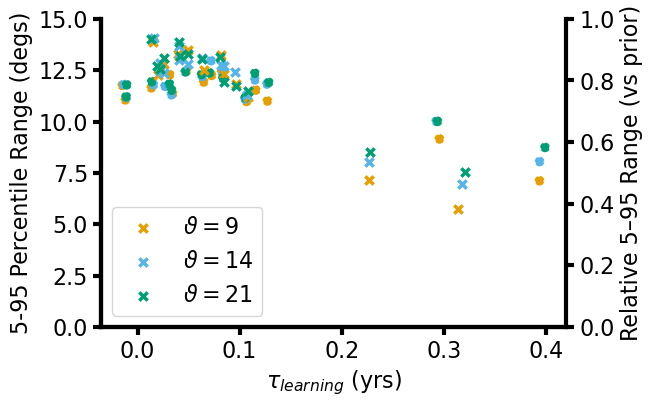

In [37]:
fig, ax = plt.subplots(figsize=(6, 4))

for i in range(len(dts_lo)):
    ax.scatter(np.nanmedian(tau_learning_lo_filtered, axis=2)[i], 
             np.nanpercentile(angles_lo_filtered[i], 95, axis=1) - np.nanpercentile(angles_lo_filtered[i], 5, axis=1),
             linestyle='dashed', color=color_list[i+1])
    
for i in range(len(dts_hi)):
    ax.scatter(np.nanmedian(tau_learning_hi_filtered, axis=2)[i], 
             np.nanpercentile(angles_hi_filtered[i], 95, axis=1) - np.nanpercentile(angles_hi_filtered[i], 5, axis=1),
             linestyle='solid', color=color_list[i+1], label=r"$\vartheta =$" + str(angles_file[i]), marker='x')
    
    
ax.legend(frameon=True)
ax.set_ylim(0, 15)
ax.set_ylabel("5-95 Percentile Range (degs)")
ax2_rel = ax.twinx()
ax2_rel.set_ylabel("Relative 5–95 Range (vs prior)")
ax2_rel.spines['right'].set_visible(True)

ax.set_xlabel(r"$\tau_{learning}$ (yrs)")

if SAVE_FIGS:
    filename = "perc-range-vs-tau-learning-AR1vsAR0.svg"
    fig.savefig(basefile + filename, dpi=350, bbox_inches='tight')
    print("Figure saved to {}".format(basefile + filename))

# ax.set_xlim(-0.05, 0.42)

Figure saved to /project/bbcael/ambauer/learning_sai/analysis/sims/figs/2026-1-22-perc-range-vs-warming-ratio-AR1vsAR0.svg


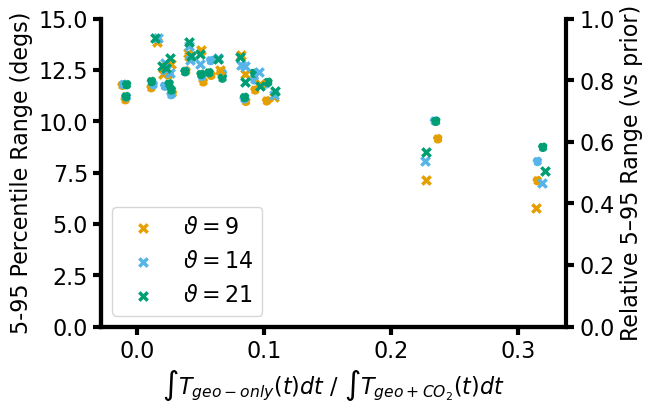

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))

for i in range(len(dts_lo)):
    ax.scatter(np.nanmedian(tau_learning_lo_filtered, axis=2)[i]/ tau_intvar, 
             np.nanpercentile(angles_lo_filtered[i], 95, axis=1) - np.nanpercentile(angles_lo_filtered[i], 5, axis=1),
             linestyle='dashed', color=color_list[i+1])
    
for i in range(len(dts_hi)):
    ax.scatter(np.nanmedian(tau_learning_hi_filtered, axis=2)[i], 
             np.nanpercentile(angles_hi_filtered[i], 95, axis=1) - np.nanpercentile(angles_hi_filtered[i], 5, axis=1),
             linestyle='solid', color=color_list[i+1], label=r"$\vartheta =$" + str(angles_file[i]), marker='x')
    
    
ax.legend(frameon=True)
ax.set_ylim(0, 15)
ax.set_ylabel("5-95 Percentile Range (degs)")
ax2_rel = ax.twinx()
ax2_rel.set_ylabel("Relative 5–95 Range (vs prior)")
ax2_rel.spines['right'].set_visible(True)

ax.set_xlabel(r"$\int T_{geo-only}(t) dt$ / $\int T_{geo + CO_2}(t) dt$")

if SAVE_FIGS:
    filename = "perc-range-vs-warming-ratio-AR1vsAR0.svg"
    fig.savefig(basefile + filename, dpi=350, bbox_inches='tight')
    print("Figure saved to {}".format(basefile + filename))

In [ ]:
import seaborn as sb
import pandas as pd

In [ ]:
np.hstack([np.arange(2027, 2050, 2), [2075, 2100]])[-2]

2075

In [ ]:
# prepare data for plotting
tr_, yr_ = 2, '2049'  # choose true value index and assimilation year ('obs up to X')
ds = dts[tr_][yr_].ds

angles_sel = angles[tr_, -3]

data = np.zeros((13, Nens))
data[0] = np.where(angles_sel > np.percentile(angles_prior, 95), np.nan, ds.controls.sel(vari='L').values)
data[1] = np.where(angles_sel > np.percentile(angles_prior, 95), np.nan, ds.controls.sel(vari='G').values)
data[2] = np.where(angles_sel > np.percentile(angles_prior, 95), np.nan, ds.controls.sel(vari='EPS').values)
data[3] = np.where(angles_sel > np.percentile(angles_prior, 95), np.nan, ds.controls.sel(vari='C1').values)
data[4] = np.where(angles_sel > np.percentile(angles_prior, 95), np.nan, ds.controls.sel(vari='C2').values)
data[5] = np.where(angles_sel > np.percentile(angles_prior, 95), np.nan, ds.controls.sel(vari='F1_CO2').values)
data[6] = np.where(angles_sel > np.percentile(angles_prior, 95), np.nan, ds.controls.sel(vari='ALPHA_R1').values)
data[7] = np.where(angles_sel > np.percentile(angles_prior, 95), np.nan, ds.controls.sel(vari='ALPHA_R2').values)
data[8] = np.where(angles_sel > np.percentile(angles_prior, 95), np.nan, ds.controls.sel(vari='BETA_R1').values/0.09)
data[9] = np.where(angles_sel > np.percentile(angles_prior, 95), np.nan, ds.controls.sel(vari='BETA_R2').values/0.09)
data[10] = np.where(angles_sel > np.percentile(angles_prior, 95), np.nan, angles_sel)
data[11] = np.where(angles_sel > np.percentile(angles_prior, 95), np.nan, data[5] / data[0])
data[12] = np.where(angles_sel > np.percentile(angles_prior, 95), np.nan, data[5] / (data[0] + data[1] * data[2]))

In [ ]:
df_all = pd.DataFrame(data=data.T,
    columns=[r'$\lambda$ (K / W m$^{-2}$)', r'$\gamma$ (K / W m$^{-2}$)', r'$\varepsilon$ ($-$)', r'$C_1$', r'$C_2$',
             r'$f^{(CO_2)}_1$ (W m$^{-2})$', r'$\alpha_{R1}$ ($-$)', r'$\alpha_{R2}$ ($-$)',
             r'$\beta_{R1}$ (K / W m$^{-2}$)', r'$\beta_{R2}$ (K / W m$^{-2}$)', r'$\vartheta$ (Degrees)', 'ECS (K)', 'TCR (K)']
)

In [ ]:
df_all

,$\lambda$ (K / W m$^{-2}$),$\gamma$ (K / W m$^{-2}$),$\varepsilon$ ($-$),$C_1$,$C_2$,$f^{(CO_2)}_1$ (W m$^{-2})$,$\alpha_{R1}$ ($-$),$\alpha_{R2}$ ($-$),$\beta_{R1}$ (K / W m$^{-2}$),$\beta_{R2}$ (K / W m$^{-2}$),$\vartheta$ (Degrees),ECS (K),TCR (K)
0,1.099552,0.602144,1.562407,6.074846,145.953288,4.736828,1.914572,1.251645,0.279652,-0.159427,16.385246,4.307961,2.321581
1,1.088971,0.642072,1.792097,8.499670,97.648952,4.913465,1.999790,1.278420,0.084855,-0.240512,12.525957,4.512026,2.193876
2,1.018189,0.637710,1.498996,7.863737,129.991261,4.525562,2.035418,1.320212,0.173608,-0.212597,12.819647,4.444715,2.292452
3,1.013917,0.656226,1.512072,5.677252,122.566559,4.562692,2.045198,1.299711,0.167359,-0.175744,11.590115,4.500066,2.274322
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,1.032273,0.719160,1.783489,6.032797,101.062125,4.731520,2.027122,1.287707,0.193993,-0.158413,13.928001,4.583593,2.043953
496,0.561495,0.658567,1.628521,10.468786,108.225369,3.859331,1.976587,1.264827,0.209750,-0.161967,10.494718,6.873312,2.361914
497,1.194472,0.970899,1.439388,3.700279,68.071998,4.934716,2.000289,1.314298,0.160961,-0.247334,17.699172,4.131295,1.903845
498,0.696502,0.996531,1.602832,5.545369,61.296310,4.228056,1.958669,1.285919,0.162479,-0.245375,16.088930,6.070411,1.843276


In [ ]:
from scipy import stats
# Assuming your dataframe is called 'df'
theta_col = r'$\vartheta$ (Degrees)'

# Get the independent variable (theta)
theta = df_all[theta_col]

results = {}
r_tot = 0

# Loop through each column
for col in df_all.columns:
    # Skip the theta column itself
    if col == theta_col or col == 'ECS (K)' or col == 'TCR (K)':
        continue
    
    # Get the dependent variable
    y = df_all[col]
    
    # Remove NaN values
    mask = ~(np.isnan(theta) | np.isnan(y))
    theta_clean = theta[mask]
    y_clean = y[mask]
    
    # Perform linear regression
    slope, intercept, r_value, p_value, std_err = stats.linregress(
        theta[mask], y[mask]
    )

    r_tot += r_value**2
    
    results[col] = {
        'slope': slope,
        'intercept': intercept,
        'r_squared': r_value**2,
        'p_value': p_value,
        'std_err': std_err
    }

# Convert to DataFrame and sort by R² (descending)
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values('r_squared', ascending=False)

print(results_df)
print(f"\n\nVariables ranked by variance explained (R²):")
print("="*60)
for i, (var, row) in enumerate(results_df.iterrows(), 1):
    print(f"{i}. {var}")
    print(f"   R² = {row['r_squared']/r_tot:.4f} ({row['r_squared']*100/r_tot:.2f}% variance explained)")
    print(f"   Slope = {row['slope']:.4f}, p-value = {row['p_value']:.4e}\n")

                                  slope   intercept  r_squared       p_value  \
$f^{(CO_2)}_1$ (W m$^{-2})$    0.064613    3.611074   0.147413  3.931744e-18   
$C_2$                         -4.224442  165.412976   0.136055  9.348769e-17   
$\beta_{R1}$ (K / W m$^{-2}$)  0.010845    0.025865   0.111977  6.840775e-14   
$\alpha_{R1}$ ($-$)           -0.020098    2.305455   0.109857  1.213294e-13   
$\gamma$ (K / W m$^{-2}$)      0.019741    0.459856   0.076325  9.072782e-10   
$\alpha_{R2}$ ($-$)           -0.006763    1.406239   0.038888  1.497028e-05   
$\lambda$ (K / W m$^{-2}$)     0.019317    0.729753   0.034766  4.333462e-05   
$\beta_{R2}$ (K / W m$^{-2}$) -0.002185   -0.178477   0.012364  1.532613e-02   
$\varepsilon$ ($-$)            0.004513    1.509193   0.006210  8.621808e-02   
$C_1$                          0.016099    7.618097   0.000321  6.970162e-01   

                                std_err  
$f^{(CO_2)}_1$ (W m$^{-2})$    0.007145  
$C_2$                          0.48

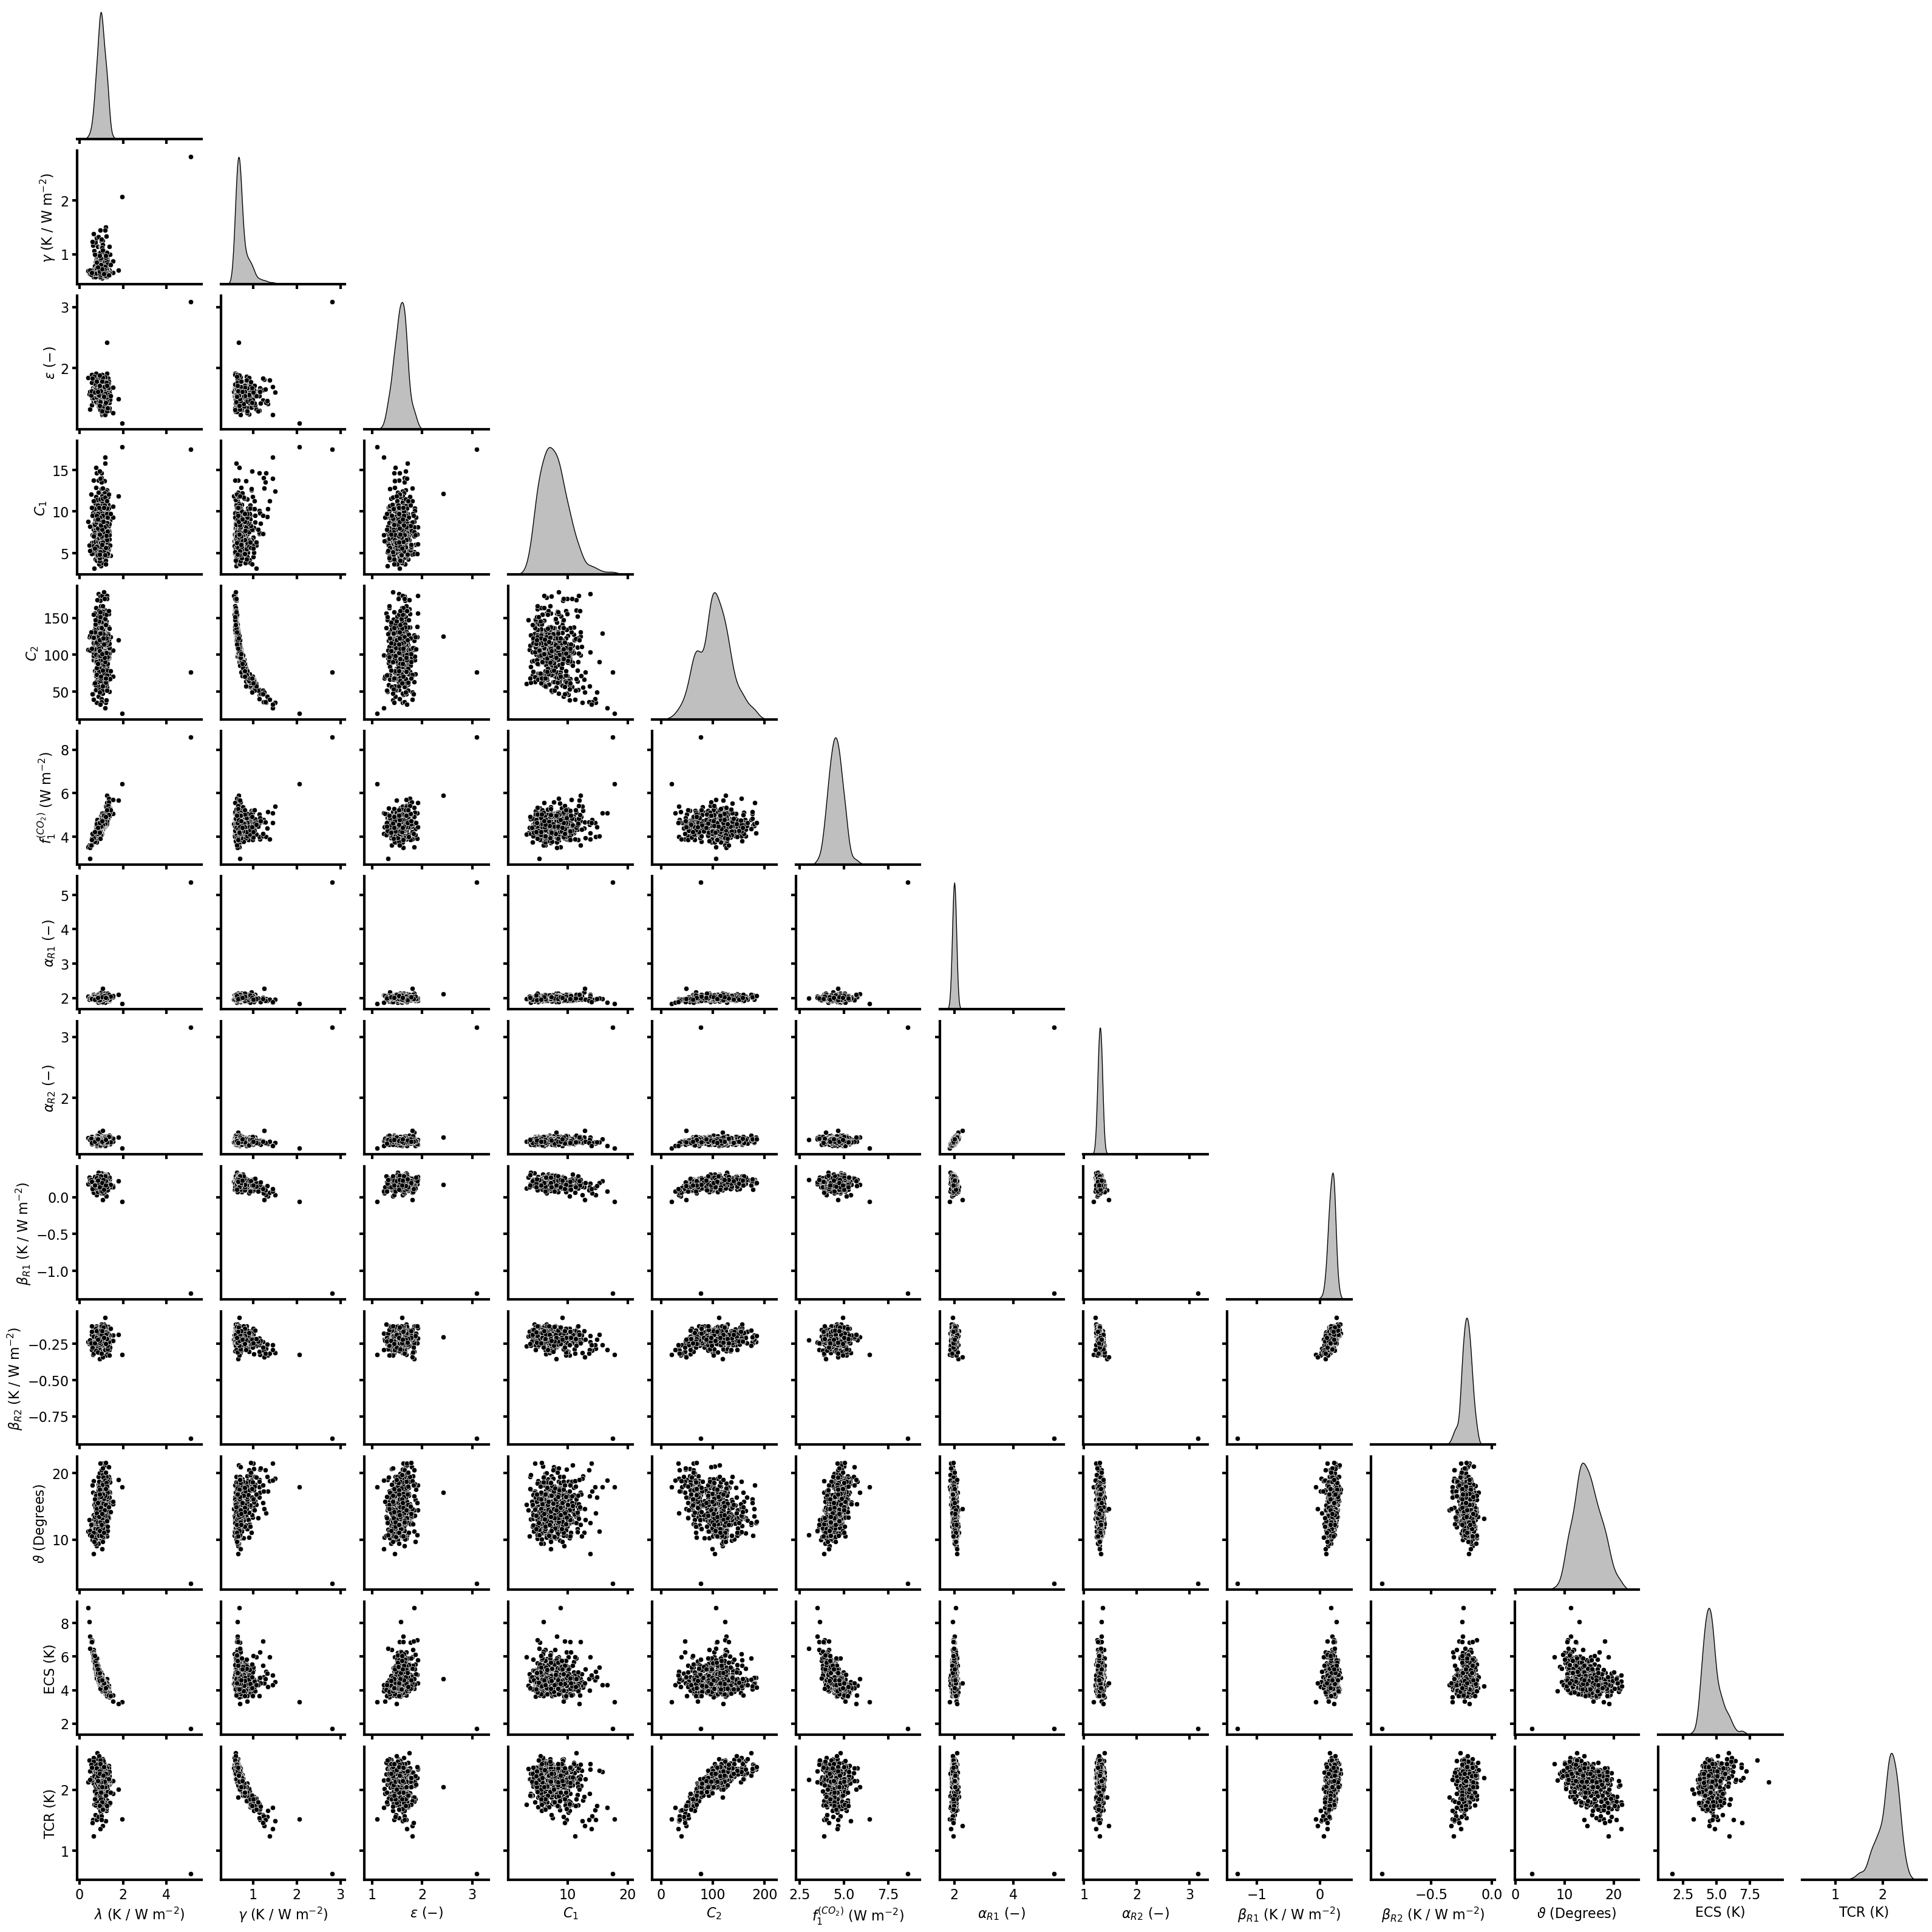

In [ ]:
pp = sb.pairplot(df_all,
                diag_kind='kde', corner=True, dropna=True)

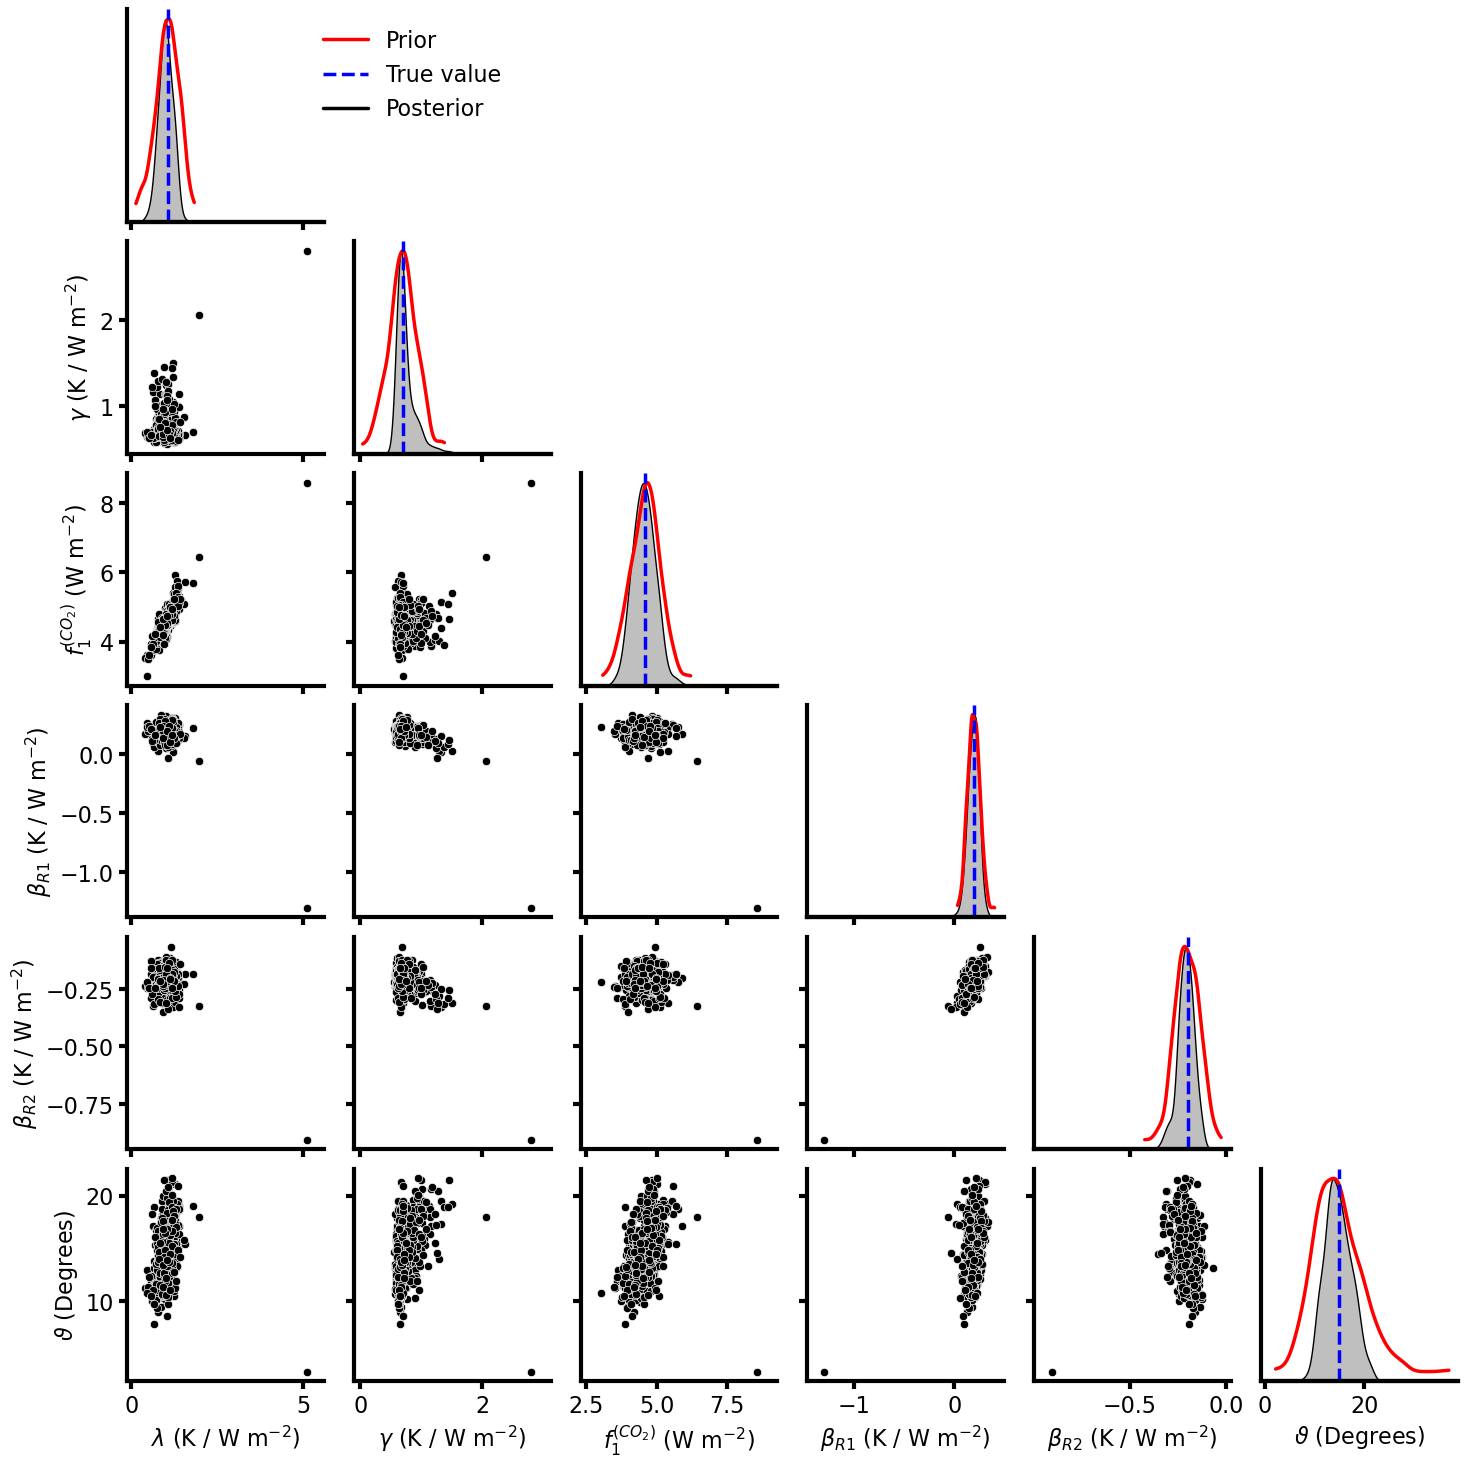

In [ ]:

pp = sb.pairplot(df_all, vars=[r'$\lambda$ (K / W m$^{-2}$)', r'$\gamma$ (K / W m$^{-2}$)',
                               r'$f^{(CO_2)}_1$ (W m$^{-2})$', r'$\beta_{R1}$ (K / W m$^{-2}$)', 
                               r'$\beta_{R2}$ (K / W m$^{-2}$)', r'$\vartheta$ (Degrees)'],
                 diag_kind='kde', corner=True, dropna=True)

prior_f = np.random.normal(4.58, 0.519, size=500)
prior_samples = [prior_l, prior_g, prior_f, prior_b1/0.09, prior_b2/0.09, angles_prior]
var_truth = [L_CEN, G_CEN, 4.58, 0.018/0.09, -0.018/0.09, angles_tr[tr_]]

# add priors on the diagonals
for i, ax in enumerate(pp.diag_axes):
    x = np.linspace(min(prior_samples[i]), max(prior_samples[i]), 200)
    zeros = np.zeros_like(x)
    
    kde = stats.gaussian_kde(prior_samples[i])

    ax2 = ax.twinx()
    ax2.plot(x, kde(x), 'r-', label='Prior', zorder=-1)
    ax2.axvline(var_truth[i], linestyle='dashed', color='b', label="True value")
    ax2.set_xlim((ax.get_xlim()[0], ax.get_xlim()[1]))
    
    #ax2.fill_between(x, zeros, kde(x), alpha=0.3, color='r', zorder=-1)
    
    ax2.set_ylabel('')
    ax2.set_yticks([])

    if i == 0:
        ax2.plot([2.0], [0], 'k-', label="Posterior")
        ax2.legend(bbox_to_anchor=(2.0, 1.0))

if SAVE_FIGS:
    filename = 'corner-regional.svg'
    # pp.savefig(basefile + filename)

In [ ]:
results_df

,slope,intercept,r_squared,p_value,std_err
$f^{(CO_2)}_1$ (W m$^{-2})$,0.080893,3.384463,0.223862,1.763979e-28,0.006846
$C_2$,-4.149393,164.372141,0.159174,5.403872e-20,0.433491
$\gamma$ (K / W m$^{-2}$),0.043454,0.129477,0.122682,1.789318e-15,0.005282
$\lambda$ (K / W m$^{-2}$),0.040390,0.436106,0.101585,6.162522e-13,0.005460
$\beta_{R1}$ (K / W m$^{-2}$),0.008345,0.060714,0.078751,3.023641e-10,0.001297
$\alpha_{R1}$ ($-$),-0.008833,2.148468,0.019219,2.190166e-03,0.002868
$\beta_{R2}$ (K / W m$^{-2}$),-0.002180,-0.178500,0.014949,6.963220e-03,0.000804
$C_1$,0.065468,6.931894,0.005891,9.097896e-02,0.038656
$\varepsilon$ ($-$),0.002423,1.538173,0.002047,3.195951e-01,0.002432
$\alpha_{R2}$ ($-$),-0.000626,1.320686,0.000284,7.108360e-01,0.001688


In [ ]:
TCRs = np.zeros_like(angles)

w_ = 0
d_ = 0
for dt in dts:
    for w in windss:
        F2x = dt[w].ds.controls.sel(vari='F1_CO2').values
        L = dt[w].ds.controls.sel(vari='L').values
        G = dt[w].ds.controls.sel(vari='G').values
        E = dt[w].ds.controls.sel(vari='EPS').values
        TCRs[d_, w_] = F2x / (L + G * E)
        w_ += 1
    d_ += 1
    w_ = 0

TCRs_filtered = np.where(angles > 40, np.nan, TCRs)

/scratch/local/jobs/43034307/ipykernel_3657920/3501822179.py:11: RuntimeWarning: overflow encountered in multiply
  TCRs[d_, w_] = F2x / (L + G * E)


Text(0.5, 0, '$\\vartheta$ 95-5 Percentile Range')

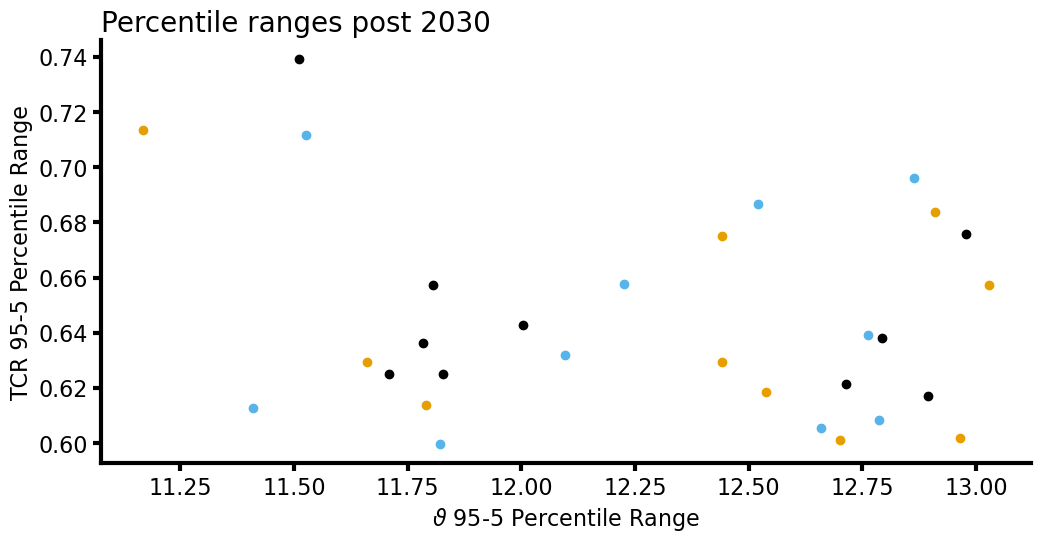

In [ ]:
up = 95
lp = 5
lb = 2
ub = -2

plt.scatter(np.nanpercentile(angles_filtered[0], up, axis=1)[lb:ub] - np.nanpercentile(angles_filtered[0], lp, axis=1)[lb:ub],
            np.nanpercentile(TCRs_filtered[0], up, axis=1)[lb:ub] - np.nanpercentile(TCRs_filtered[0], lp, axis=1)[lb:ub])

plt.scatter(np.nanpercentile(angles_filtered[1], up, axis=1)[lb:ub] - np.nanpercentile(angles_filtered[1], lp, axis=1)[lb:ub],
            np.nanpercentile(TCRs_filtered[1], up, axis=1)[lb:ub] - np.nanpercentile(TCRs_filtered[1], lp, axis=1)[lb:ub])

plt.scatter(np.nanpercentile(angles_filtered[2], up, axis=1)[lb:ub] - np.nanpercentile(angles_filtered[2], lp, axis=1)[lb:ub],
            np.nanpercentile(TCRs_filtered[2], up, axis=1)[lb:ub] - np.nanpercentile(TCRs_filtered[2], lp, axis=1)[lb:ub])

plt.title("Percentile ranges post 2030")
plt.ylabel("TCR 95-5 Percentile Range")
plt.xlabel(r"$\vartheta$ 95-5 Percentile Range")

In [ ]:
np.nanpercentile(angles_filtered[0], 95, axis=1) - np.nanpercentile(angles_filtered[0], 5, axis=1)


array([16.01771145, 10.01815212,  9.1642755 ,  8.45085075,  8.585393  ,
        8.51978014,  8.66425231,  8.76037209,  7.59673509,  8.21912802,
        7.4736056 ,  7.55186424,  7.15401912,  4.89916573,  4.65988329])

In [ ]:
from scipy.stats import describe

describe(angles[0, 2]).mean

14.871032470055844

(array([  1.,   6.,  20.,  61., 115., 132., 101.,  50.,  11.,   3.]),
 array([ 4.94258756,  6.75201492,  8.56144229, 10.37086966, 12.18029703,
        13.9897244 , 15.79915177, 17.60857914, 19.4180065 , 21.22743387,
        23.03686124]),
 <BarContainer object of 10 artists>)

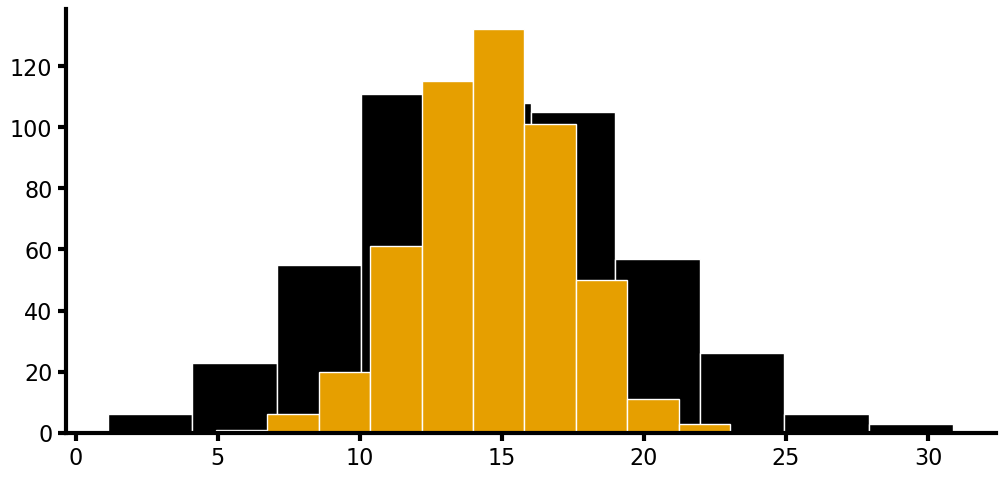

In [ ]:
plt.hist(angles_prior)
plt.hist(angles[1, 3])

In [ ]:
angles_filtered = np.where(angles > 40, np.nan, angles)
angles_filtered

array([[[12.2808719 , 21.0173075 , 10.69008267, ...,  9.8047894 ,
          9.96688122, 12.50763725],
        [13.92075851, 18.30913514, 16.80098746, ..., 12.65852142,
         18.45609059, 15.08528691],
        [14.68584015, 18.43115577, 15.2822881 , ..., 11.73759066,
         15.5495521 , 13.80605778],
        ...,
        [14.72233635, 13.02911581, 13.51261472, ..., 13.67794241,
         14.51194408, 15.13896651],
        [16.43712839, 13.04752022, 10.83421087, ..., 12.04520787,
         13.24759367,  0.0428931 ],
        [11.1024485 , 13.41730529, 12.01935743, ..., 15.58836531,
         12.17021758, 13.20540263]],

       [[12.2808719 , 21.0173075 , 10.69008267, ...,  9.8047894 ,
          9.96688122, 12.50763725],
        [14.02529536, 18.41729672, 16.83666826, ..., 12.74124134,
         18.58518115, 15.00064089],
        [14.68334974, 18.5620946 , 15.45406808, ..., 13.48817713,
         15.78113123, 13.92521928],
        ...,
        [15.7024941 , 14.13420785, 15.05921122, ..., 1

(array([  1.,   6.,  20.,  61., 115., 132., 101.,  50.,  11.,   3.]),
 array([ 4.94258756,  6.75201492,  8.56144229, 10.37086966, 12.18029703,
        13.9897244 , 15.79915177, 17.60857914, 19.4180065 , 21.22743387,
        23.03686124]),
 <BarContainer object of 10 artists>)

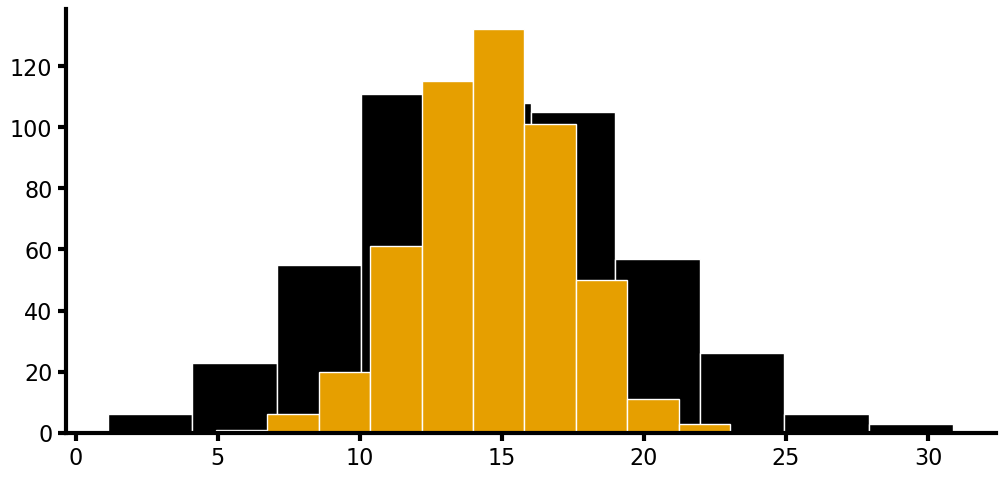

In [ ]:
plt.hist(angles_prior)
plt.hist(angles_filtered[1, 3])

In [ ]:
x = ['tat', 'tdo', 'q', 'tr1', 'tr2', 'l', 'g', 'e', 'c1', 'c2', 'f1', 'a1', 'a2', 'b1', 'b2', 'else']

In [ ]:
x


['tat',
 'tdo',
 'q',
 'tr1',
 'tr2',
 'l',
 'g',
 'e',
 'c1',
 'c2',
 'f1',
 'a1',
 'a2',
 'b1',
 'b2',
 'else']

In [ ]:
x[5:13]

['l', 'g', 'e', 'c1', 'c2', 'f1', 'a1', 'a2']

In [ ]:
x[5:12]

['l', 'g', 'e', 'c1', 'c2', 'f1', 'a1']

In [ ]:
x[5:14]

['l', 'g', 'e', 'c1', 'c2', 'f1', 'a1', 'a2', 'b1']

# OLD STUFF THAT IS DEPRECIATED AND / OR WRONG

In [ ]:
# THIS IS OLD AND DEPRECIATED
def get_angle_OLD(a1, b1, a2, b2, a1cent, a2cent, lam, f_eff):
    # convert betas into xis
    prefactor1 = lam / (f_eff * a1cent)
    prefactor2 = lam / (f_eff * a2cent)
    xi1 = b1 * prefactor1
    xi2 = b2 * prefactor2

    # coefficient on SAI contribution to temperature rise
    comp1 = a1cent * (xi1 - 1)
    comp2 = a2cent * (xi2 - 1)

    # angle components
    ang_num = a1 * b1 + a2 * b2
    ang_denom = np.sqrt(
        (a1**2 + a2**2) * (b1**2 + b2**2)
    )
    return np.arccos(ang_num / ang_denom) * 180 / np.pi